# Intrinsic Timescales (INT) Computation via Impulse Stimulation Method

## Overview

This notebook implements the first method described in **Deco et al. (2021)** for computing intrinsic timescales in brain network models. We will analyze the temporal decay dynamics of regional activity following impulse stimulation to characterize the intrinsic timescales of each brain region in our fitted models.

## Background and Motivation

Intrinsic timescales reflect the duration over which neural activity remains correlated with itself, providing insights into the hierarchical organization of brain dynamics. Different brain regions exhibit distinct timescales that are thought to reflect their functional roles - from fast sensory processing to slow integrative functions.

## Methodology

### Theoretical Framework

Following **Chaudhuri et al. (2015)** and **Deco et al. (2021)**, we examine activity timescales by analyzing the rate at which regional activity decays following impulse stimulation. This approach provides a direct measure of how long neural activity persists in each brain region after a brief perturbation.

### Stimulation Protocol

- **Pre-stimulation phase**: 3000 ms under spontaneous conditions to eliminate transients
- **Stimulation phase**: 1000 ms impulse stimulation (from 3000ms to 4000ms)
- **Post-stimulation phase**: 3000 ms relaxation period (from 4000ms to 7000ms) with external stimulation reset to zero
- **Target stimulation site**: Lateral occipital region
- **Analysis scope**: All brain regions (as targets for decay analysis)
- **Repetitions**: 1000 simulations for statistical robustness
### Mathematical Model

The temporal decay of regional firing rates follows an exponential decay function:

$$r^{E}_i(t) = A × exp(-D × t) + B$$


Where:
- $r^{E}_i(t)$: Firing rate (Hz) of region i at time t after stimulation
- `t`: Time after stimulation (seconds)
- `D`: **Decay rate parameter** (our primary measure of intrinsic timescale)
- `A`: Scaling constant (amplitude of decay)
- `B`: Offset parameter (baseline firing rate)

### Key Analysis Steps

1. **Simulation Setup and Stimulation Phase**
   - Run whole-brain model for 3000 ms under spontaneous conditions (eliminate transients)
   - Apply 1000 ms impulse stimulation to lateral occipital region (3000-4000 ms)
   - Allow 3000 ms relaxation period with stimulation reset to zero (4000-7000 ms)
   - Record the response across all brain regions throughout the entire 7000 ms simulation

2. **Recording Phase**
   - Monitor firing rates in all brain regions following stimulation
   - Record temporal evolution of activity for sufficient duration
   - Repeat for 1000 independent simulations

3. **Data Processing**
   - Average firing rate trajectories across 1000 simulations
   - Extract post-stimulation time series (4000-7000 ms period) for each brain region
   - Focus analysis on the decay dynamics during the relaxation phase
   - Prepare data for exponential curve fitting
   
4. **Curve Fitting**
   - Fit exponential decay model using **nonlinear least squares**
   - Extract decay rate parameter `D` for each brain region
   - Compute **intrinsic timescale** as `τ = 1/D` (in seconds)

5. **Analysis and Visualization**
   - Compare timescales across brain regions
   - Examine relationship with T1w/T2w hierarchy
   - Validate fits and assess goodness-of-fit metrics

## Hypotheses

From **Deco et al. (2021)** 
- A clear trend is evident for rapid decay in visual regions and more prolonged responses in prefrontal areas
- A significant positive correlation between regional decay values and an independent measure of cortical hierarchy, T1w:T2w


## Expected Outputs

- **Regional decay curves**: Visualization of firing rate decay for each brain region
- **Fitted parameters**: Decay rates (D), scaling factors (A), and offsets (B) for all regions
- **Intrinsic timescales**: Timescale values (τ = 1/D) for hierarchical analysis
- **Quality metrics**: R-squared values and residual analysis for fit validation
- **Comparative analysis**: Regional differences and potential functional implications

## Implementation Strategy

The notebook will proceed through the following phases:

1. **Setup and Configuration**: Load fitted models, define stimulation parameters
2. **Simulation Loop**: Run 1000 stimulation trials with data collection
3. **Data Aggregation**: Average responses and prepare for curve fitting
4. **Exponential Fitting**: Apply nonlinear least squares to extract timescales
5. **Results Analysis**: Visualization and interpretation of regional timescales

## References

1. **Deco, G., Kringelbach, M. L., Arnatkeviciute, A., Oldham, S., Sabaroedin, K., Rogasch, N. C., Aquino, K. M., & Fornito, A. (2021)**. Dynamical consequences of regional heterogeneity in the brain's transcriptional landscape. *Science Advances*, *7*(29), eabf4752. [https://doi.org/10.1126/sciadv.abf4752](https://doi.org/10.1126/sciadv.abf4752)

2. **Chaudhuri, R., Knoblauch, K., Gariel, M.-A., Kennedy, H., & Wang, X.-J. (2015)**. A Large-Scale Circuit Mechanism for Hierarchical Dynamical Processing in the Primate Cortex. *Neuron*, *88*(2), 419–431. [https://doi.org/10.1016/j.neuron.2015.09.008](https://doi.org/10.1016/j.neuron.2015.09.008)

---

**Note**: This implementation focuses on the first timescale measurement method from Deco et al. (2021). The second method (autocorrelation-based) may be implemented in a separate notebook for comparison.


## Simulation Setup

In [2]:
from hbnm.intrinsic_timescales import (
    load_config, ModelLoader, StimulationSimulator, DataProcessor, 
    CurveFitter, ResultsSaver
)

# Complete intrinsic timescales analysis workflow
config = load_config("nmda_avg")

# Load and configure model
loader = ModelLoader(config)
model_data = loader.load_model()

# Run stimulation experiment
simulator = StimulationSimulator(config)
raw_results = simulator.run_stimulation_experiment(model_data)

# Process data for curve fitting
processor = DataProcessor(config)
decay_data = processor.extract_decay_period(raw_results)

# Fit exponential decay curves to extract intrinsic timescales
fitter = CurveFitter(config)
timescale_results = fitter.fit_decay_curves(decay_data)



=== LOADING MODEL WITH CONFIG ===
Step 1: Loading structural connectivity...
  Regions: 180
Step 2: Finding model parameters...
  ✓ Auto-detected latest iteration: 41
Step 3: Loading parameters from NMDA_AVG/iteration_41.hdf5...
Step 4: Computing Bayesian Model Average...
Step 5: Formatting parameters...
  Model type: heterogeneous
  Samples: 300 | Parameters: 5
Step 6: Loading heterogeneity maps...
  Map loaded: (1, 180) | Invert flags: [False]

✓ Heterogeneous model loaded successfully!
  Parameters:
    w_EI: (0.2394, 0.9560) [baseline, scaling]
    w_EE: (0.4622, 2.2340) [baseline, scaling]
    G: 0.8774
=== STARTING STIMULATION EXPERIMENT ===
Step 1: Creating stimulation protocol...
  Protocol: Single pulse
  Target: Region 0 | Amplitude: 0.1nA
  Duration: 1.0s | Total time: 7.0s
  Sampling: 1000Hz | Array shape: (70001, 180)
Step 2: Preparing parallel simulation...
  Available cores: 96
  Using cores: 10 (limited by config: 10)
Step 3: Running 100 trials on 10 cores...
  Complete

In [4]:
import numpy as np

In [5]:
# Get w_EI and w_EE for each region (base + scale * hmap value)
nmda_map = np.load('/home/frank/HBNM/data/heterogeneity_vectors/linearized/NMDA_linearized.npy') # Note shape is (1, 180)

# Parameters from your config
w_EI_baseline = 0.2394
w_EI_scaling = 0.9560
w_EE_baseline = 0.4622  
w_EE_scaling = 2.2340

timepoints = decay_data['time_relative']
firing_rates = decay_data['firing_rates']

# Calculate w_EI and w_EE for each region
# nmda_map is shape (1, 180), so we take the first row
nmda_values = nmda_map[0, :]  # Shape: (180,)

w_EI_values = w_EI_baseline + w_EI_scaling * nmda_values
w_EE_values = w_EE_baseline + w_EE_scaling * nmda_values

print(f"NMDA map range: {np.min(nmda_values):.4f} to {np.max(nmda_values):.4f}")
print(f"w_EI range: {np.min(w_EI_values):.4f} to {np.max(w_EI_values):.4f}")
print(f"w_EE range: {np.min(w_EE_values):.4f} to {np.max(w_EE_values):.4f}")
print(f"Number of regions: {len(nmda_values)}")

NMDA map range: -0.9998 to 0.9918
w_EI range: -0.7164 to 1.1876
w_EE range: -1.7713 to 2.6779
Number of regions: 180


In [6]:
# Check for decay vs sustain by comparing first 0.1s vs last 0.1s
timepoints = np.array(timepoints)
firing_rates = np.array(firing_rates)

# Find indices for first 0.1s and last 0.1s
first_0_1s_mask = timepoints <= 0.1
last_0_1s_mask = timepoints >= (np.max(timepoints) - 0.1)

print(f"First 0.1s: {np.sum(first_0_1s_mask)} timepoints")
print(f"Last 0.1s: {np.sum(last_0_1s_mask)} timepoints")
print(f"First 0.1s time range: {np.min(timepoints[first_0_1s_mask]):.3f} to {np.max(timepoints[first_0_1s_mask]):.3f}s")
print(f"Last 0.1s time range: {np.min(timepoints[last_0_1s_mask]):.3f} to {np.max(timepoints[last_0_1s_mask]):.3f}s")

# Calculate mean firing rate for first and last 0.1s for each region
n_regions = firing_rates.shape[0]
first_0_1s_rates = np.zeros(n_regions)
last_0_1s_rates = np.zeros(n_regions)
decay_sustain_values = np.zeros(n_regions)

for region in range(n_regions):
    # Mean firing rate in first 0.1s
    first_0_1s_rates[region] = np.mean(firing_rates[region, first_0_1s_mask])
    
    # Mean firing rate in last 0.1s  
    last_0_1s_rates[region] = np.mean(firing_rates[region, last_0_1s_mask])
    
    # Calculate change: positive = sustain/increase, negative = decay
    decay_sustain_values[region] = last_0_1s_rates[region] - first_0_1s_rates[region]

# Summary statistics
sustaining_regions = np.sum(decay_sustain_values > 0)
decaying_regions = np.sum(decay_sustain_values < 0)
stable_regions = np.sum(decay_sustain_values == 0)

print(f"\nRegion behavior summary:")
print(f"  Sustaining (positive change): {sustaining_regions} ({100*sustaining_regions/n_regions:.1f}%)")
print(f"  Decaying (negative change): {decaying_regions} ({100*decaying_regions/n_regions:.1f}%)")
print(f"  Stable (no change): {stable_regions} ({100*stable_regions/n_regions:.1f}%)")

print(f"\nDecay/sustain statistics:")
print(f"  Mean change: {np.mean(decay_sustain_values):.4f} Hz")
print(f"  Std change: {np.std(decay_sustain_values):.4f} Hz") 
print(f"  Range: {np.min(decay_sustain_values):.4f} to {np.max(decay_sustain_values):.4f} Hz")

First 0.1s: 101 timepoints
Last 0.1s: 101 timepoints
First 0.1s time range: 0.000 to 0.100s
Last 0.1s time range: 2.900 to 3.000s

Region behavior summary:
  Sustaining (positive change): 175 (97.2%)
  Decaying (negative change): 5 (2.8%)
  Stable (no change): 0 (0.0%)

Decay/sustain statistics:
  Mean change: 1.0028 Hz
  Std change: 1.5230 Hz
  Range: -1.4675 to 7.2458 Hz


In [7]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Create dataframe with all the data
analysis_df = pd.DataFrame({
    'region_idx': np.arange(n_regions),
    'nmda_value': nmda_values,
    'w_EI': w_EI_values,
    'w_EE': w_EE_values,
    'first_0_1s_rate': first_0_1s_rates,
    'last_0_1s_rate': last_0_1s_rates,
    'decay_sustain': decay_sustain_values,  # negative = decay, positive = sustain
    'is_sustaining': decay_sustain_values > 0
})

# print("Analysis DataFrame created:")
# print(analysis_df.head())
# print(f"\nDataFrame shape: {analysis_df.shape}")

# Analyze relationships
print(f"\n=== CORRELATION ANALYSIS ===")

# w_EI vs decay/sustain
corr_EI, p_val_EI = pearsonr(analysis_df['w_EI'], analysis_df['decay_sustain'])
spearman_EI, sp_p_val_EI = spearmanr(analysis_df['w_EI'], analysis_df['decay_sustain'])

print(f"w_EI vs decay_sustain:")
print(f"  Pearson correlation: {corr_EI:.4f} (p={p_val_EI:.6f})")
print(f"  Spearman correlation: {spearman_EI:.4f} (p={sp_p_val_EI:.6f})")

# w_EE vs decay/sustain  
corr_EE, p_val_EE = pearsonr(analysis_df['w_EE'], analysis_df['decay_sustain'])
spearman_EE, sp_p_val_EE = spearmanr(analysis_df['w_EE'], analysis_df['decay_sustain'])

print(f"\nw_EE vs decay_sustain:")
print(f"  Pearson correlation: {corr_EE:.4f} (p={p_val_EE:.6f})")
print(f"  Spearman correlation: {spearman_EE:.4f} (p={sp_p_val_EE:.6f})")

# NMDA vs decay/sustain
corr_NMDA, p_val_NMDA = pearsonr(analysis_df['nmda_value'], analysis_df['decay_sustain'])
spearman_NMDA, sp_p_val_NMDA = spearmanr(analysis_df['nmda_value'], analysis_df['decay_sustain'])

print(f"\nNMDA value vs decay_sustain:")
print(f"  Pearson correlation: {corr_NMDA:.4f} (p={p_val_NMDA:.6f})")
print(f"  Spearman correlation: {spearman_NMDA:.4f} (p={sp_p_val_NMDA:.6f})")

# Compare sustaining vs decaying regions
sustaining_df = analysis_df[analysis_df['is_sustaining'] == True]
decaying_df = analysis_df[analysis_df['is_sustaining'] == False]

print(f"\n=== GROUP COMPARISON ===")
print(f"Sustaining regions (n={len(sustaining_df)}):")
print(f"  w_EI: {sustaining_df['w_EI'].mean():.4f} ± {sustaining_df['w_EI'].std():.4f}")
print(f"  w_EE: {sustaining_df['w_EE'].mean():.4f} ± {sustaining_df['w_EE'].std():.4f}")
print(f"  NMDA: {sustaining_df['nmda_value'].mean():.4f} ± {sustaining_df['nmda_value'].std():.4f}")

print(f"\nDecaying regions (n={len(decaying_df)}):")
print(f"  w_EI: {decaying_df['w_EI'].mean():.4f} ± {decaying_df['w_EI'].std():.4f}")
print(f"  w_EE: {decaying_df['w_EE'].mean():.4f} ± {decaying_df['w_EE'].std():.4f}")
print(f"  NMDA: {decaying_df['nmda_value'].mean():.4f} ± {decaying_df['nmda_value'].std():.4f}")

# Statistical tests for group differences
from scipy.stats import mannwhitneyu

stat_EI, p_EI = mannwhitneyu(sustaining_df['w_EI'], decaying_df['w_EI'], alternative='two-sided')
stat_EE, p_EE = mannwhitneyu(sustaining_df['w_EE'], decaying_df['w_EE'], alternative='two-sided')
stat_NMDA, p_NMDA = mannwhitneyu(sustaining_df['nmda_value'], decaying_df['nmda_value'], alternative='two-sided')

print(f"\nMann-Whitney U tests (sustaining vs decaying):")
print(f"  w_EI difference: p = {p_EI:.6f}")
print(f"  w_EE difference: p = {p_EE:.6f}")  
print(f"  NMDA difference: p = {p_NMDA:.6f}")

if p_EI < 0.05:
    print("  🚨 SIGNIFICANT w_EI difference between sustaining and decaying regions!")
if p_EE < 0.05:
    print("  🚨 SIGNIFICANT w_EE difference between sustaining and decaying regions!")
if p_NMDA < 0.05:
    print("  🚨 SIGNIFICANT NMDA difference between sustaining and decaying regions!")


=== CORRELATION ANALYSIS ===
w_EI vs decay_sustain:
  Pearson correlation: -0.6408 (p=0.000000)
  Spearman correlation: -0.6762 (p=0.000000)

w_EE vs decay_sustain:
  Pearson correlation: -0.6408 (p=0.000000)
  Spearman correlation: -0.6762 (p=0.000000)

NMDA value vs decay_sustain:
  Pearson correlation: -0.6408 (p=0.000000)
  Spearman correlation: -0.6762 (p=0.000000)

=== GROUP COMPARISON ===
Sustaining regions (n=175):
  w_EI: 0.2715 ± 0.5285
  w_EE: 0.5373 ± 1.2349
  NMDA: 0.0336 ± 0.5528

Decaying regions (n=5):
  w_EI: -0.0531 ± 0.6761
  w_EE: -0.2214 ± 1.5799
  NMDA: -0.3060 ± 0.7072

Mann-Whitney U tests (sustaining vs decaying):
  w_EI difference: p = 0.234154
  w_EE difference: p = 0.234154
  NMDA difference: p = 0.234154


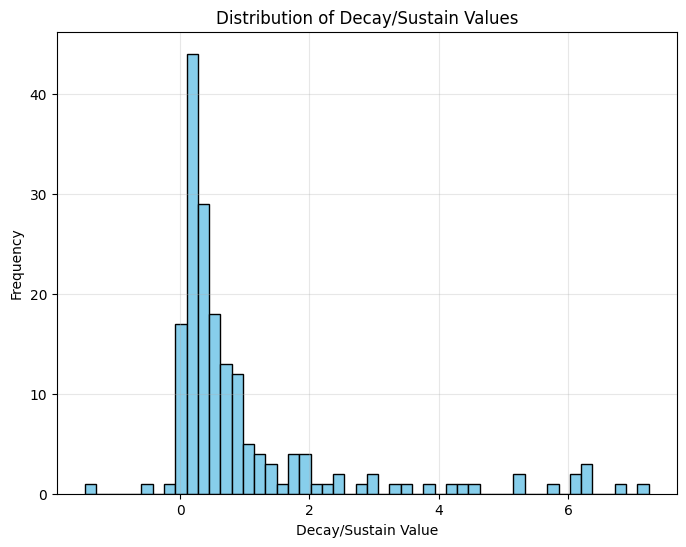

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(analysis_df['decay_sustain'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Decay/Sustain Values')
plt.xlabel('Decay/Sustain Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
num_w_EI_pos = (analysis_df['w_EI'] > 0).sum()
num_w_EI_neg = (analysis_df['w_EI'] < 0).sum()
num_w_EE_pos = (analysis_df['w_EE'] > 0).sum()
num_w_EE_neg = (analysis_df['w_EE'] < 0).sum()

w_EI_pos_vals = analysis_df.loc[analysis_df['w_EI'] > 0, 'w_EI']
w_EI_neg_vals = analysis_df.loc[analysis_df['w_EI'] < 0, 'w_EI']
w_EE_pos_vals = analysis_df.loc[analysis_df['w_EE'] > 0, 'w_EE']
w_EE_neg_vals = analysis_df.loc[analysis_df['w_EE'] < 0, 'w_EE']

print(f"w_EI: {num_w_EI_pos} positive (mean={w_EI_pos_vals.mean():.4f}, sd={w_EI_pos_vals.std():.4f}), "
      f"{num_w_EI_neg} negative (mean={w_EI_neg_vals.mean():.4f}, sd={w_EI_neg_vals.std():.4f})")
print(f"w_EE: {num_w_EE_pos} positive (mean={w_EE_pos_vals.mean():.4f}, sd={w_EE_pos_vals.std():.4f}), "
      f"{num_w_EE_neg} negative (mean={w_EE_neg_vals.mean():.4f}, sd={w_EE_neg_vals.std():.4f})")

w_EI: 121 positive (mean=0.5767, sd=0.3142), 59 negative (mean=-0.3819, sd=0.2133)
w_EE: 118 positive (mean=1.2837, sd=0.7130), 62 negative (mean=-0.9444, sd=0.5265)


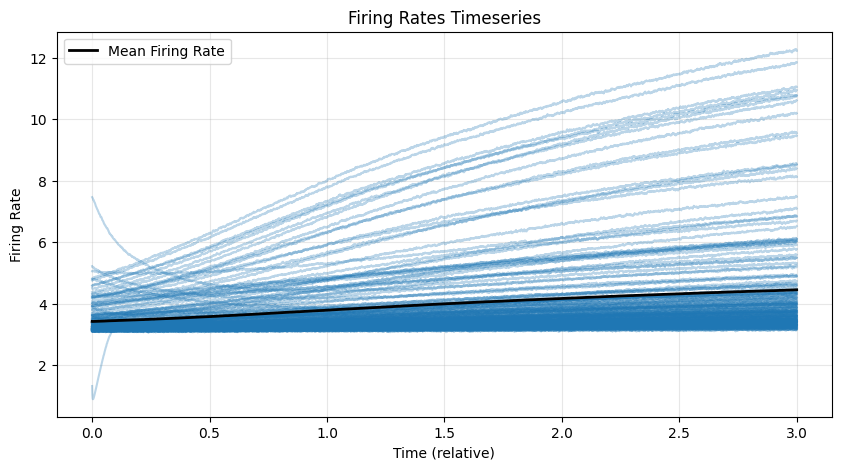

In [15]:
plt.figure(figsize=(10, 5))

# If decay_data['firing_rates'] is (n_regions, n_timepoints), plot each region
firing_rates = decay_data['firing_rates']
time = decay_data['time_relative']

if firing_rates.ndim == 2:
    # Plot all regions as semi-transparent lines
    for i in range(firing_rates.shape[0]):
        plt.plot(time, firing_rates[i], alpha=0.3, color='tab:blue')
    # Optionally, plot the mean across regions
    mean_firing = firing_rates.mean(axis=0)
    plt.plot(time, mean_firing, color='black', label='Mean Firing Rate', linewidth=2)
else:
    plt.plot(time, firing_rates, label='Firing Rate')

plt.xlabel('Time (relative)')
plt.ylabel('Firing Rate')
plt.title('Firing Rates Timeseries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Plotting raw_results[0] ---


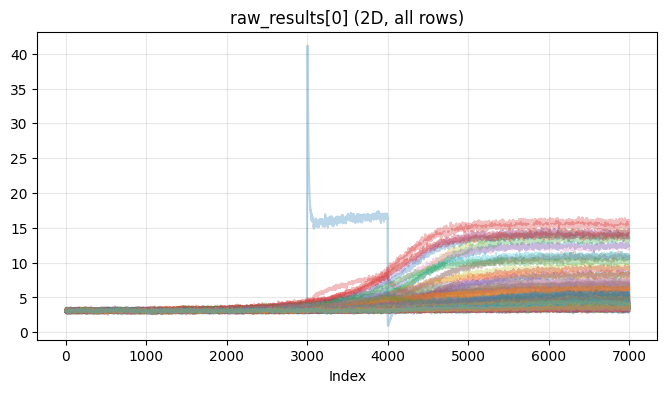

--- Plotting raw_results[1] ---


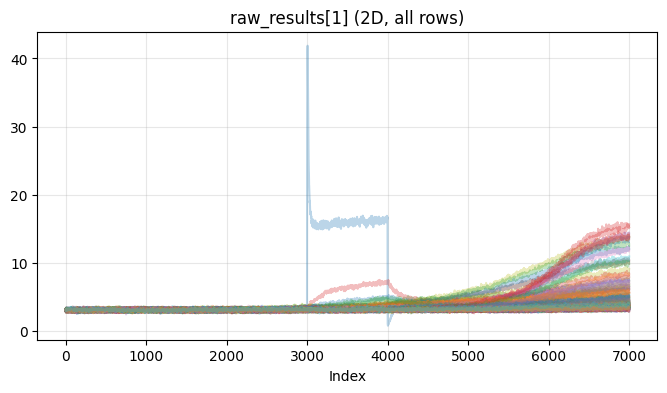

--- Plotting raw_results[2] ---


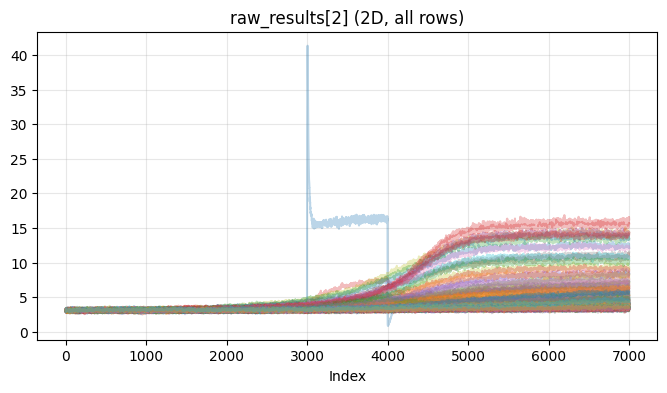

--- Plotting raw_results[3] ---


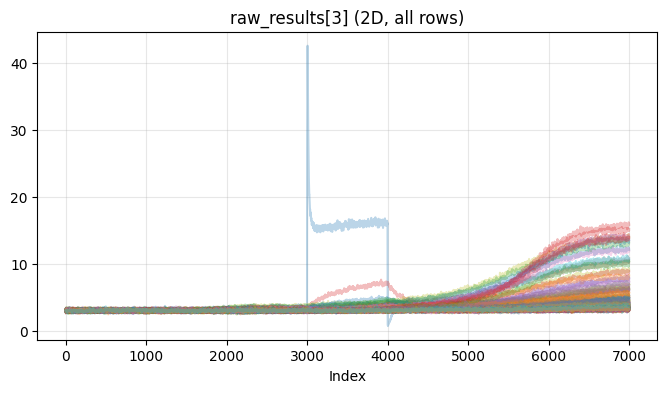

--- Plotting raw_results[4] ---


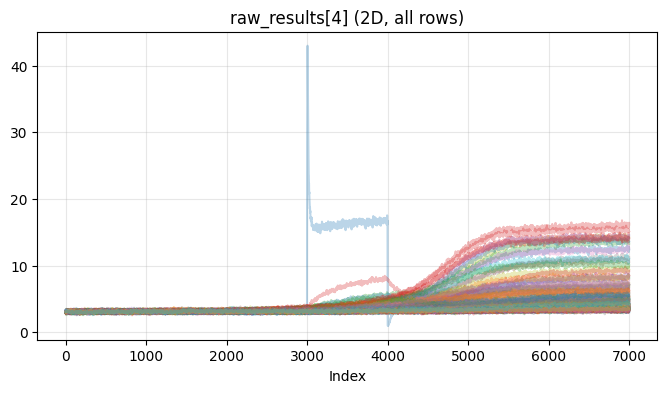

--- Plotting raw_results[5] ---


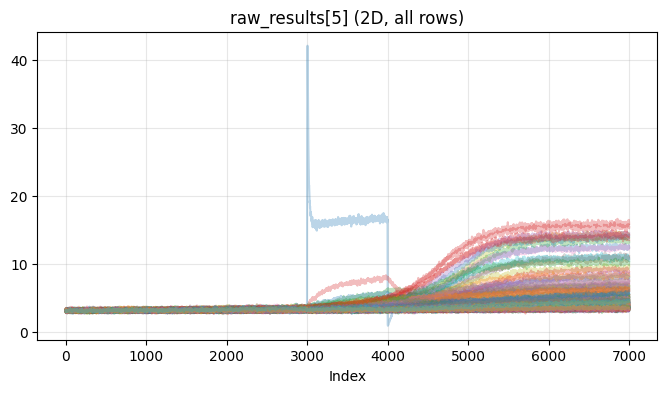

--- Plotting raw_results[6] ---


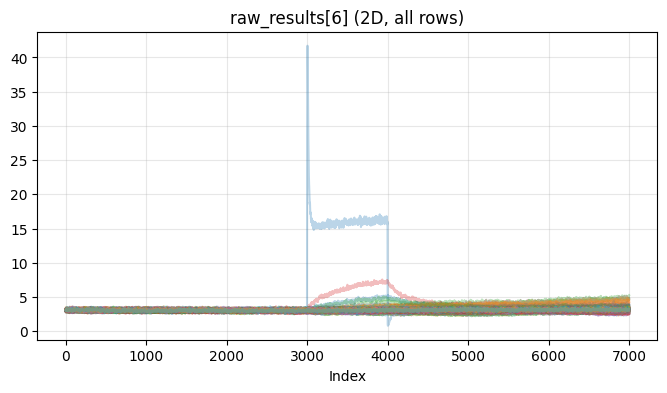

--- Plotting raw_results[7] ---


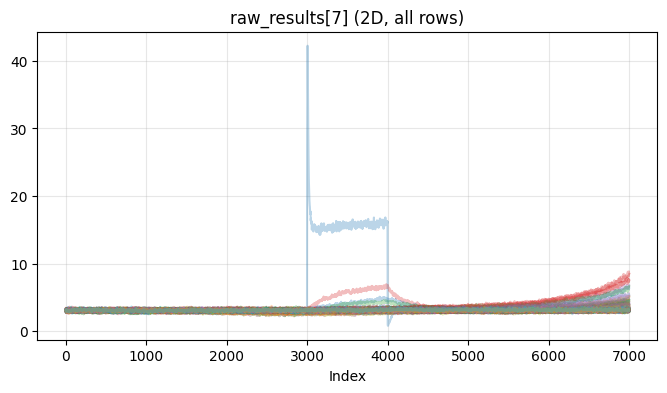

--- Plotting raw_results[8] ---


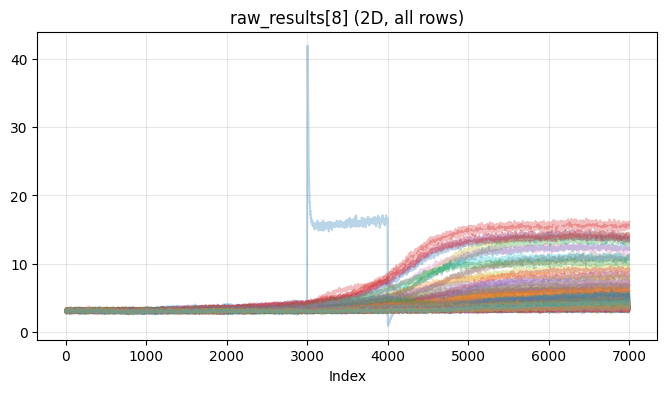

--- Plotting raw_results[9] ---


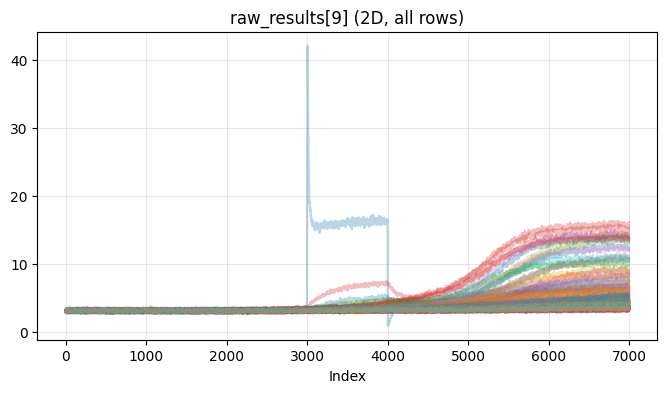

--- Plotting raw_results[10] ---


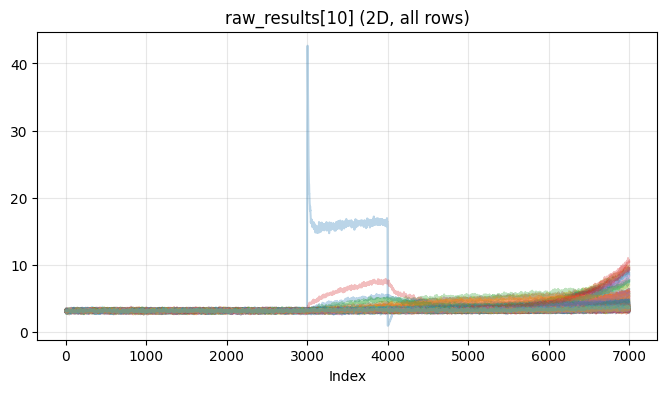

--- Plotting raw_results[11] ---


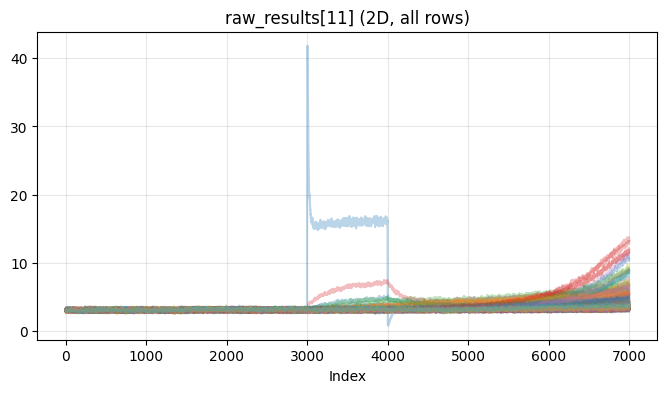

--- Plotting raw_results[12] ---


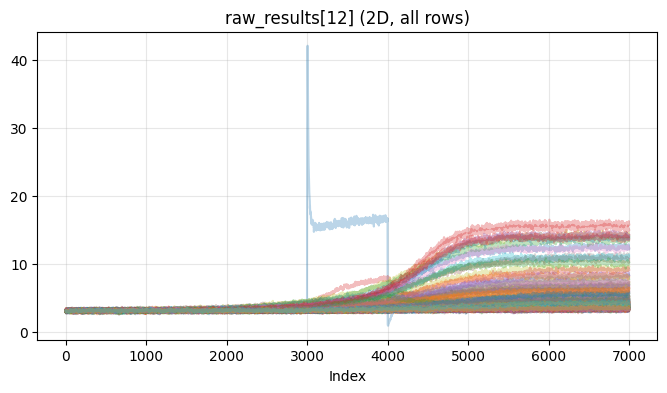

--- Plotting raw_results[13] ---


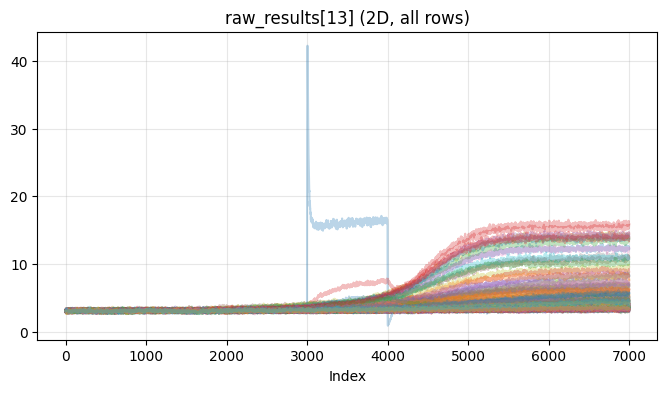

--- Plotting raw_results[14] ---


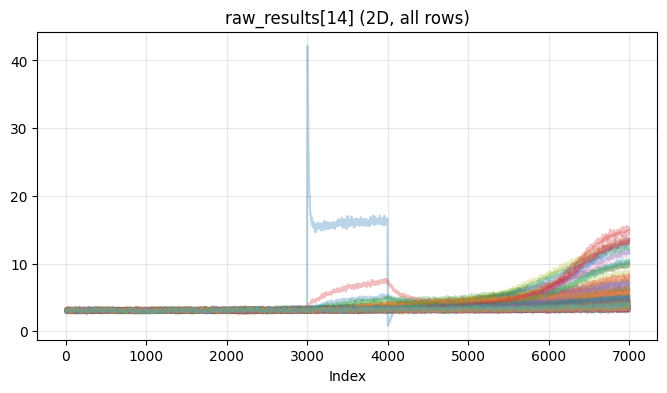

--- Plotting raw_results[15] ---


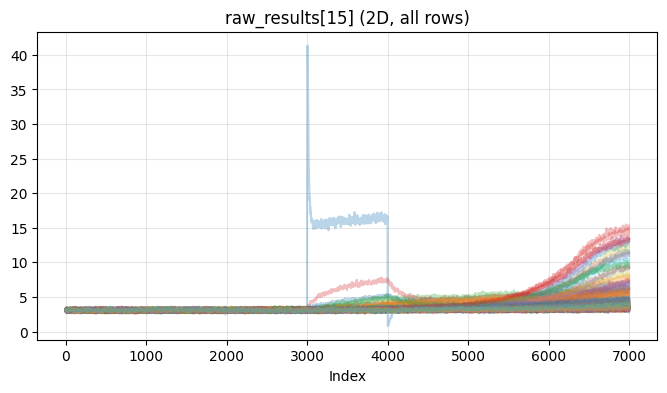

--- Plotting raw_results[16] ---


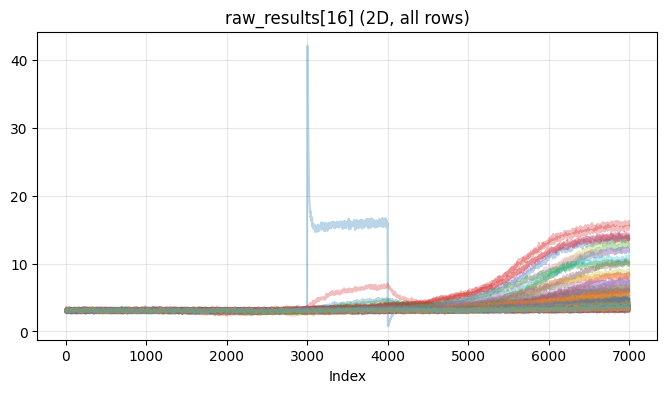

--- Plotting raw_results[17] ---


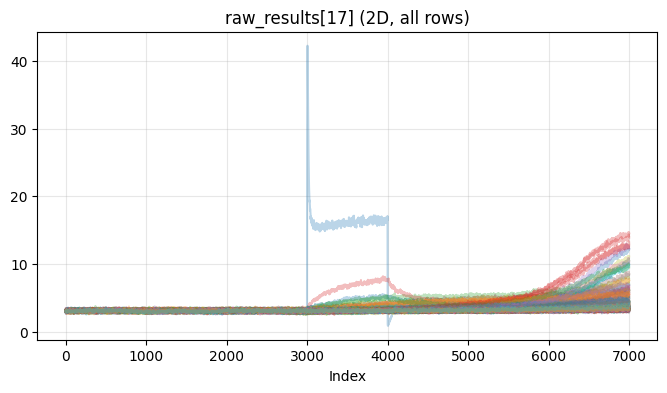

--- Plotting raw_results[18] ---


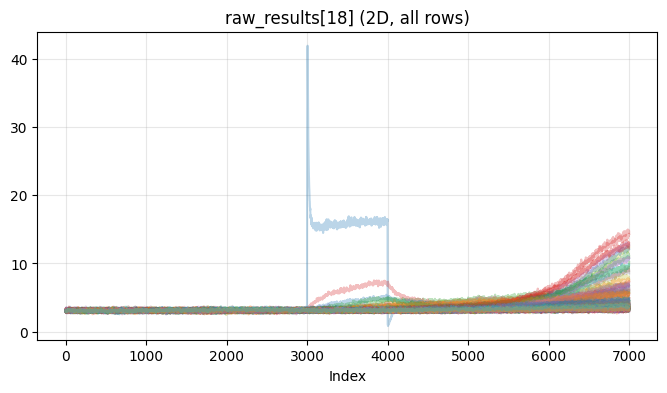

--- Plotting raw_results[19] ---


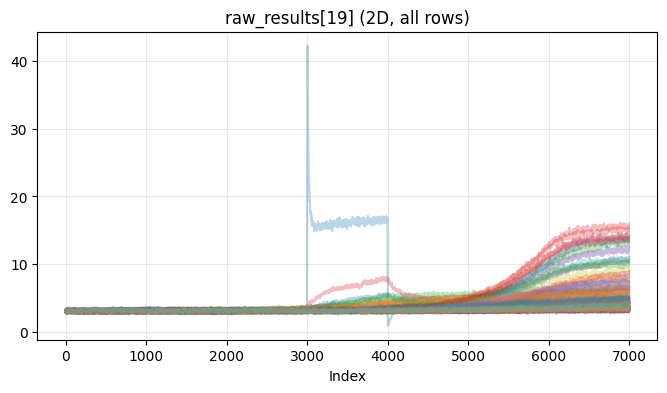

--- Plotting raw_results[20] ---


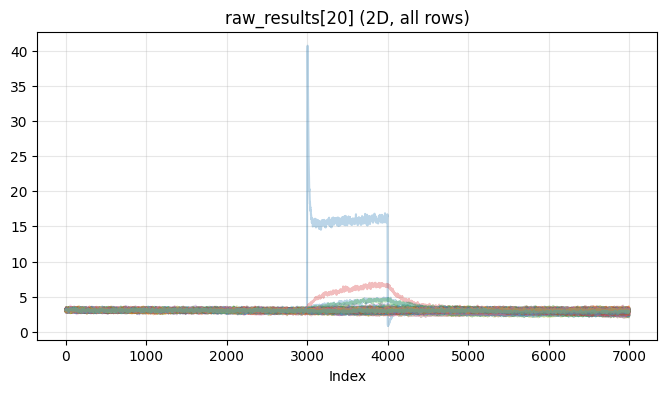

--- Plotting raw_results[21] ---


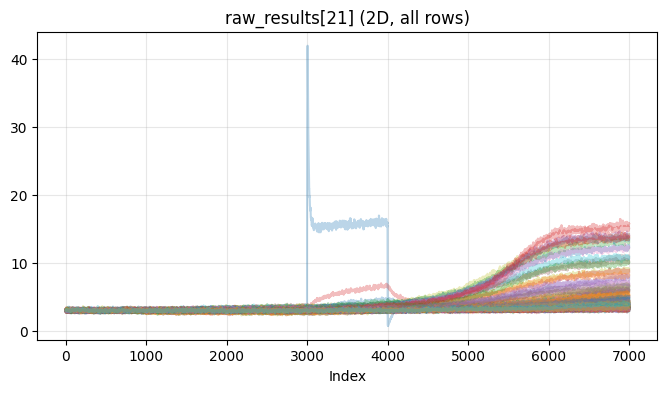

--- Plotting raw_results[22] ---


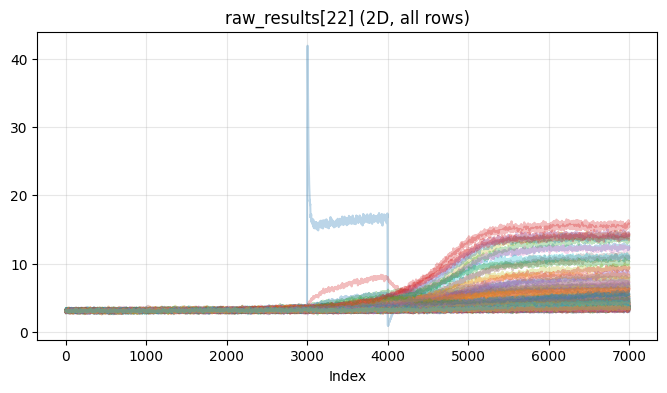

--- Plotting raw_results[23] ---


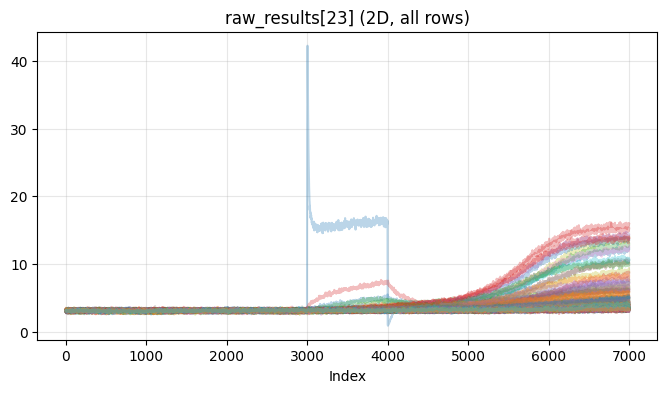

--- Plotting raw_results[24] ---


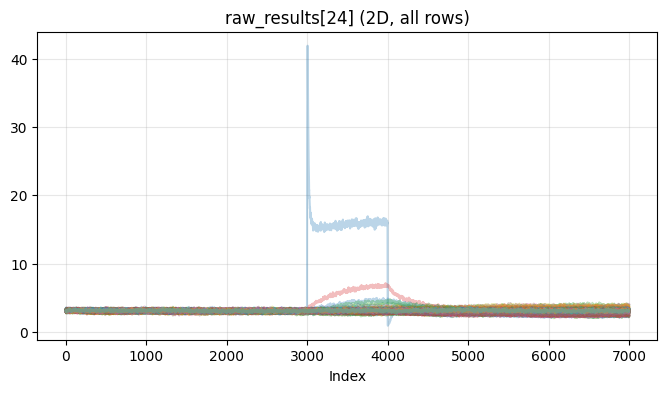

--- Plotting raw_results[25] ---


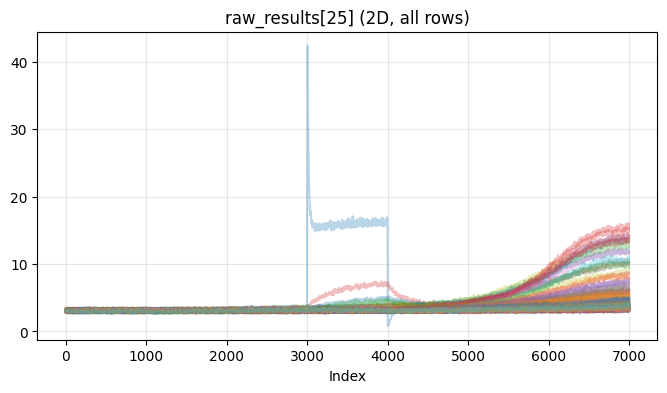

--- Plotting raw_results[26] ---


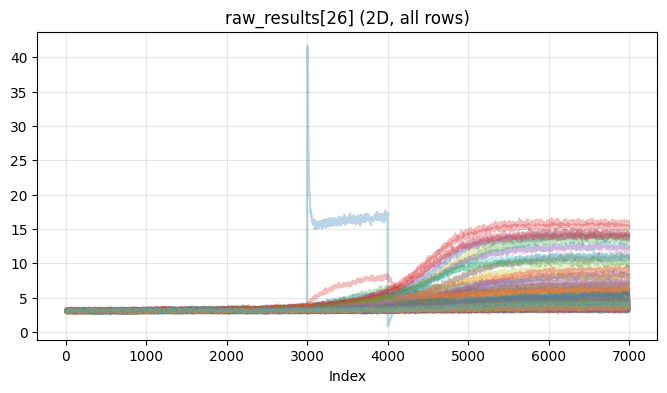

--- Plotting raw_results[27] ---


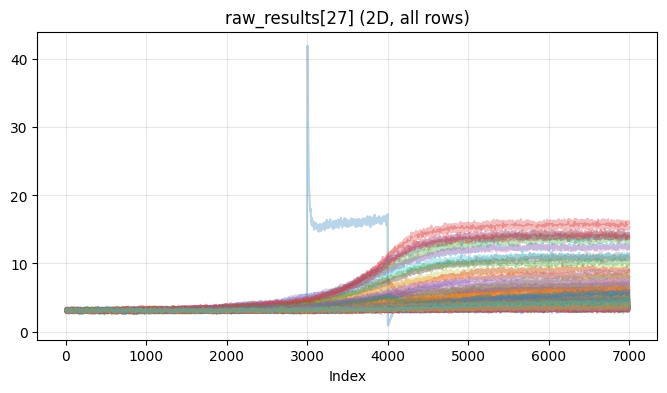

--- Plotting raw_results[28] ---


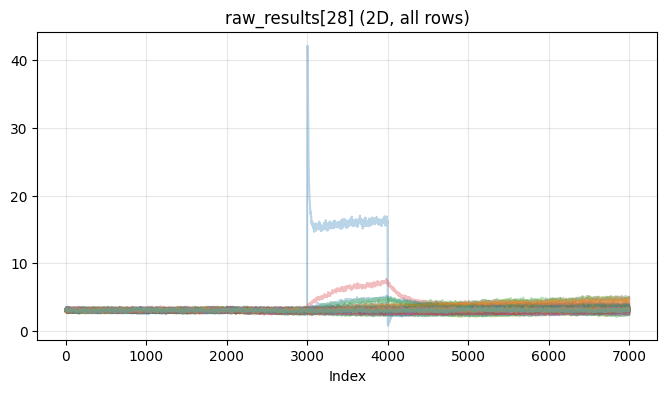

--- Plotting raw_results[29] ---


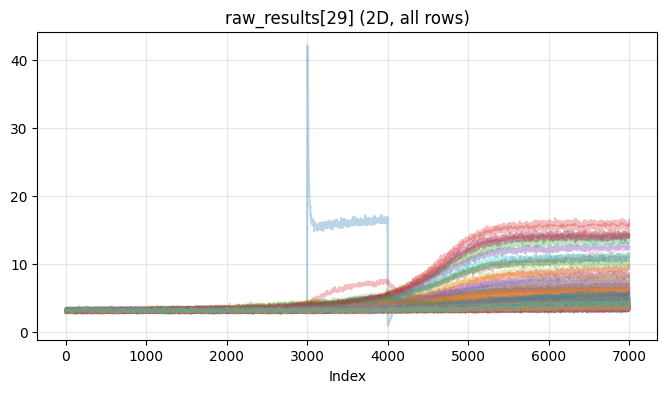

--- Plotting raw_results[30] ---


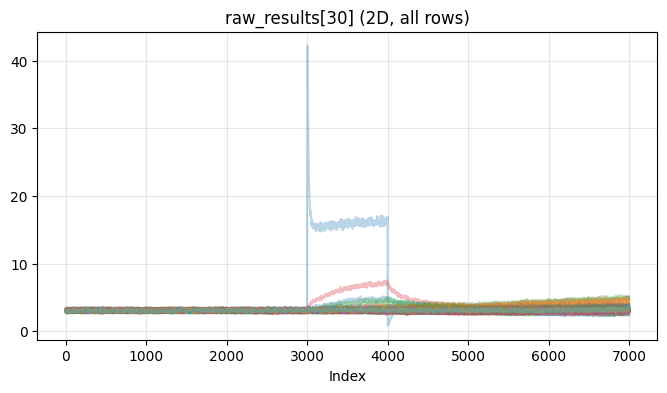

--- Plotting raw_results[31] ---


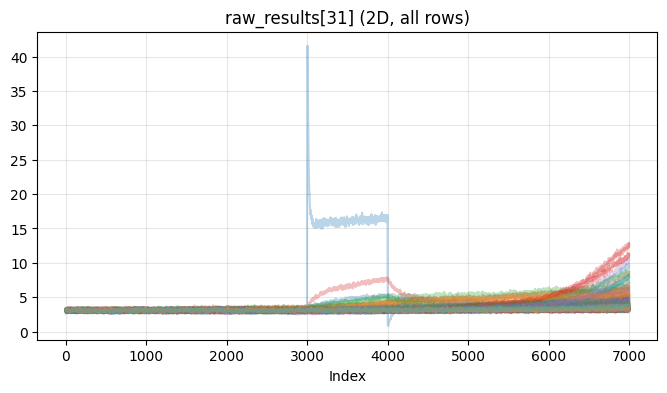

--- Plotting raw_results[32] ---


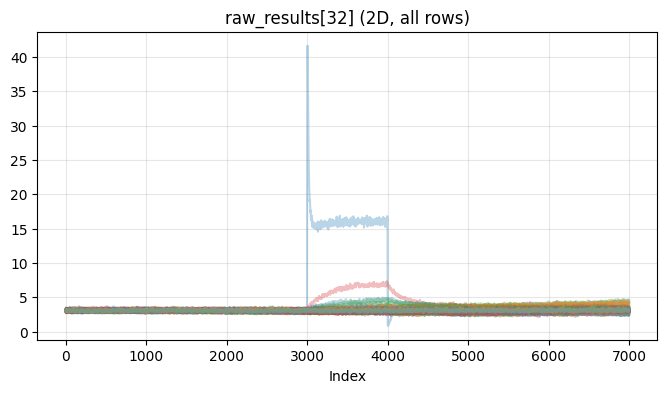

--- Plotting raw_results[33] ---


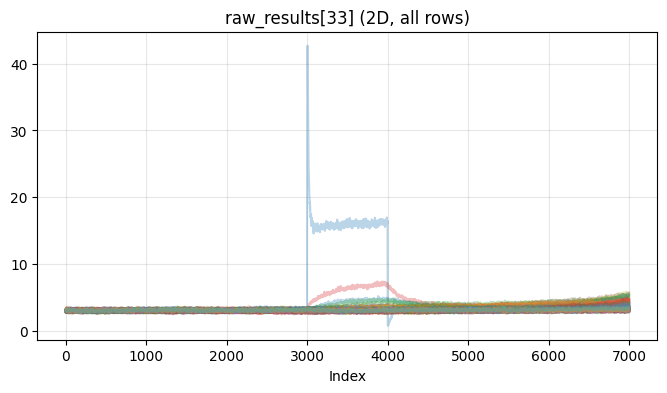

--- Plotting raw_results[34] ---


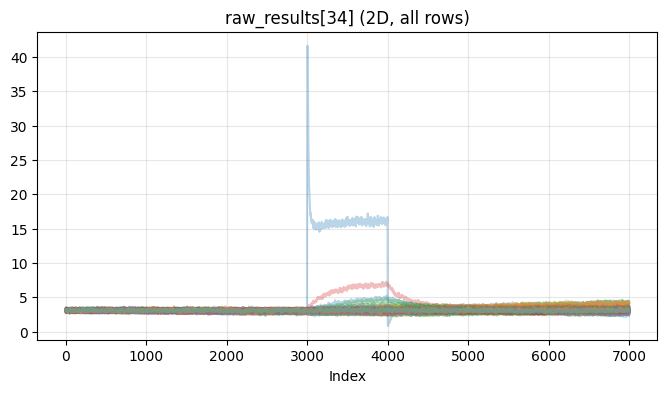

--- Plotting raw_results[35] ---


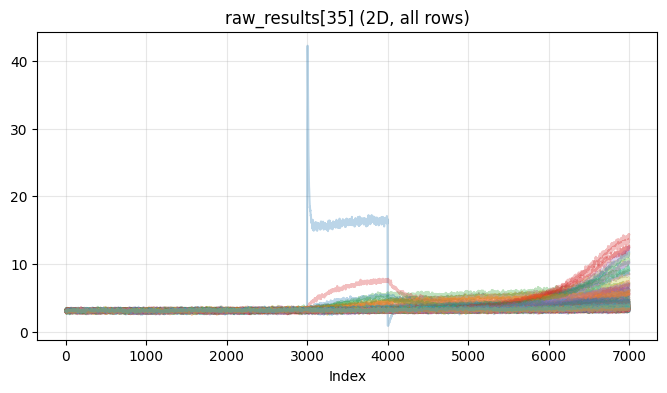

--- Plotting raw_results[36] ---


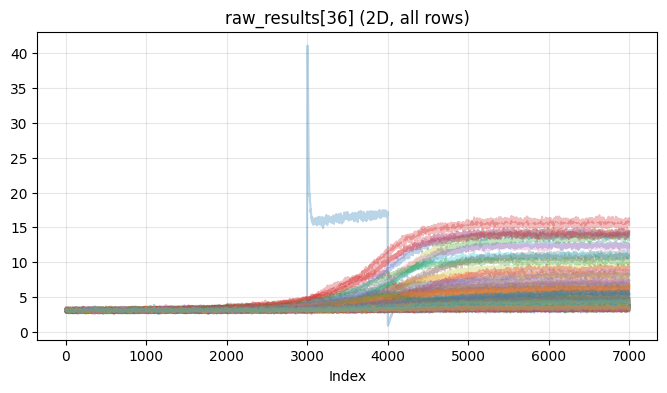

--- Plotting raw_results[37] ---


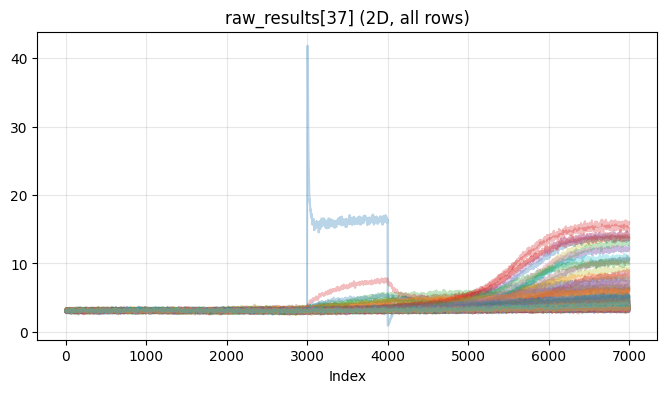

--- Plotting raw_results[38] ---


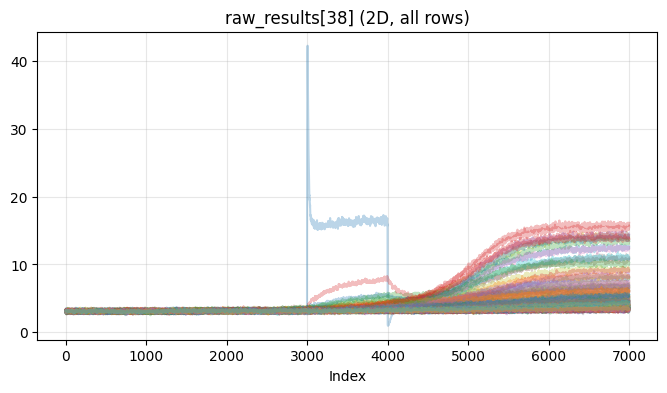

--- Plotting raw_results[39] ---


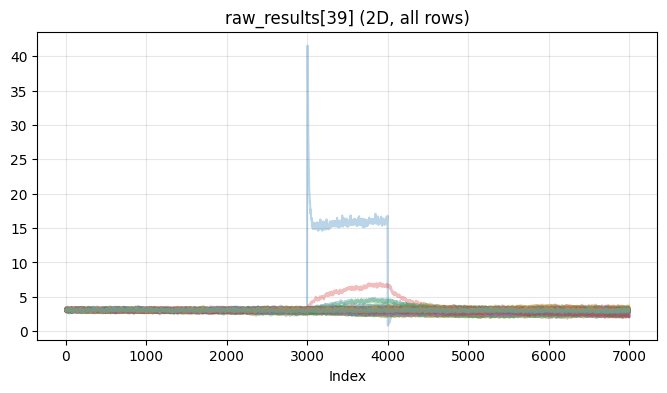

--- Plotting raw_results[40] ---


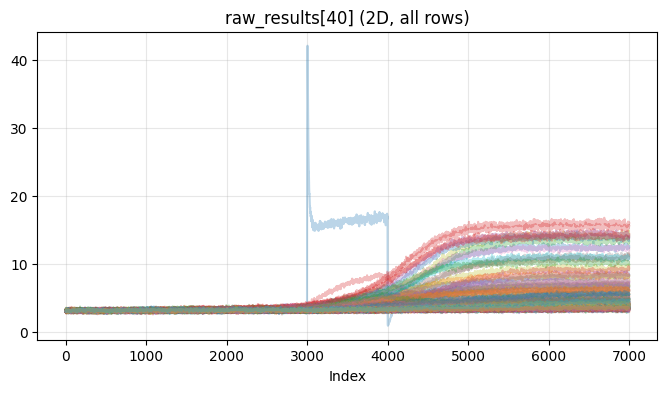

--- Plotting raw_results[41] ---


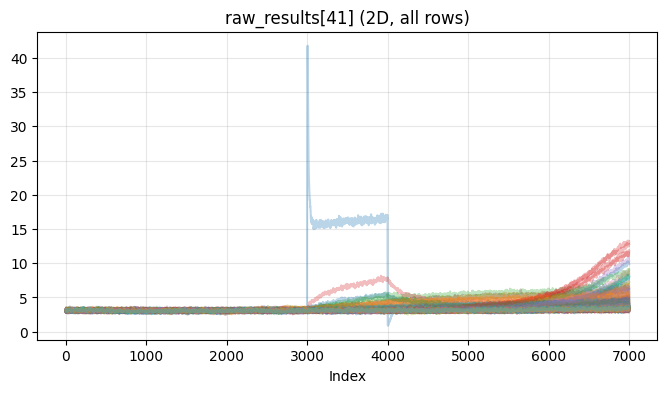

--- Plotting raw_results[42] ---


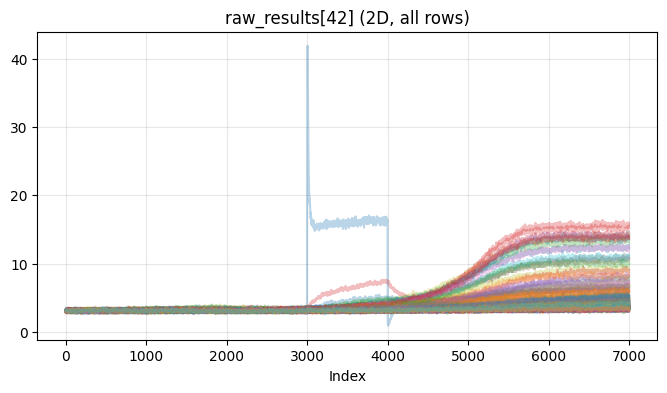

--- Plotting raw_results[43] ---


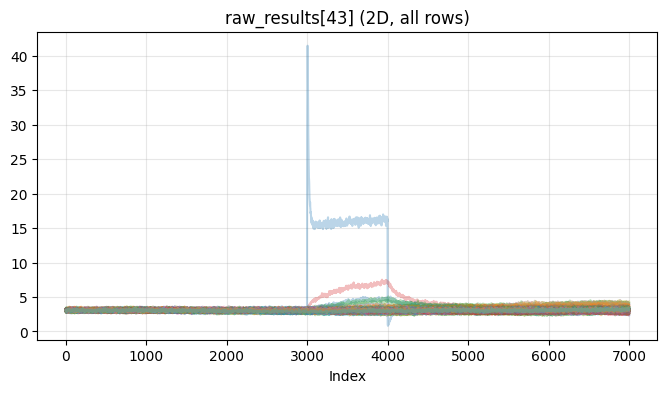

--- Plotting raw_results[44] ---


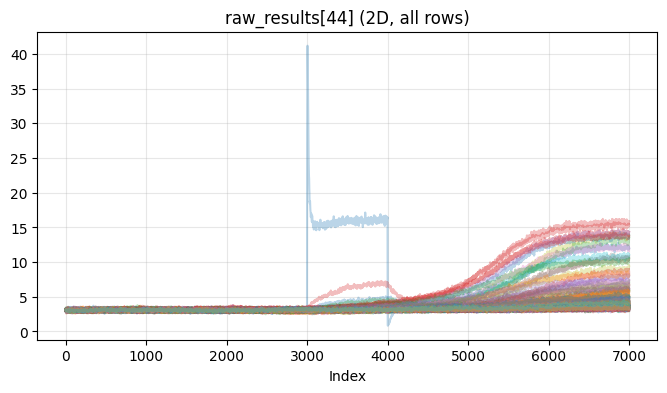

--- Plotting raw_results[45] ---


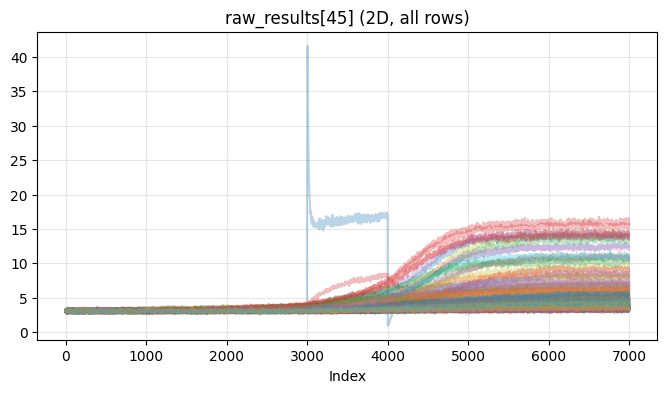

--- Plotting raw_results[46] ---


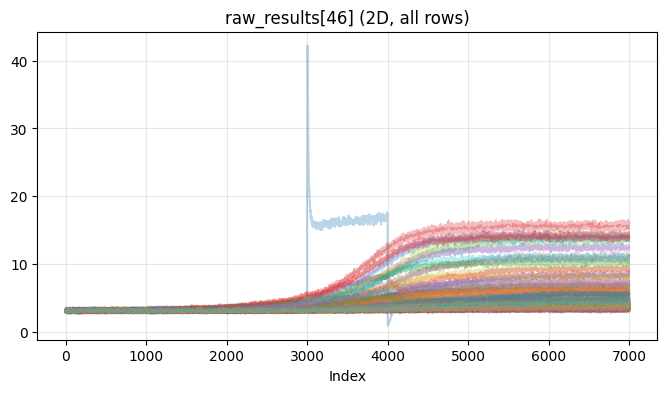

--- Plotting raw_results[47] ---


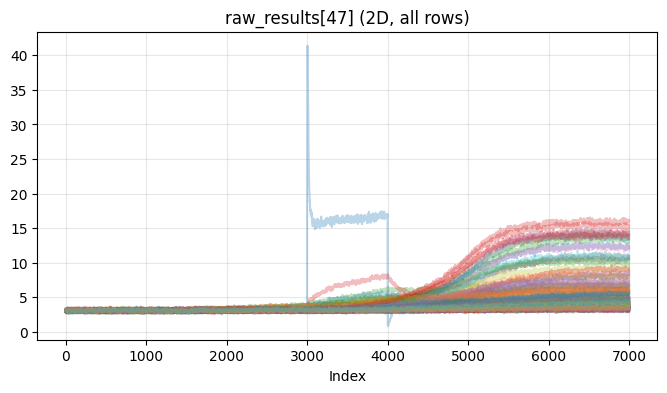

--- Plotting raw_results[48] ---


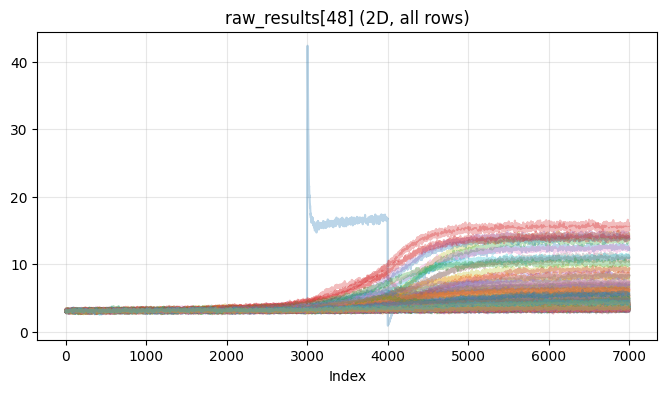

--- Plotting raw_results[49] ---


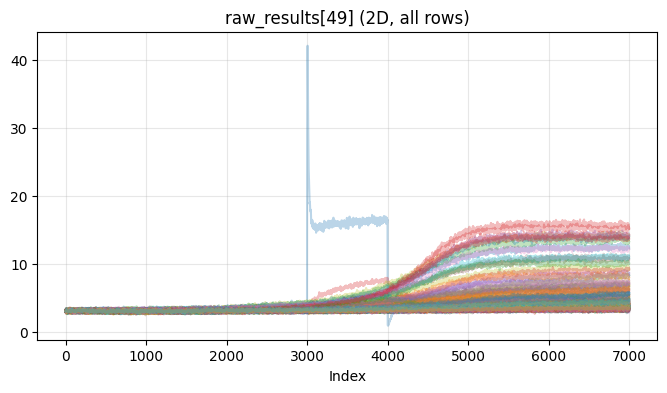

--- Plotting raw_results[50] ---


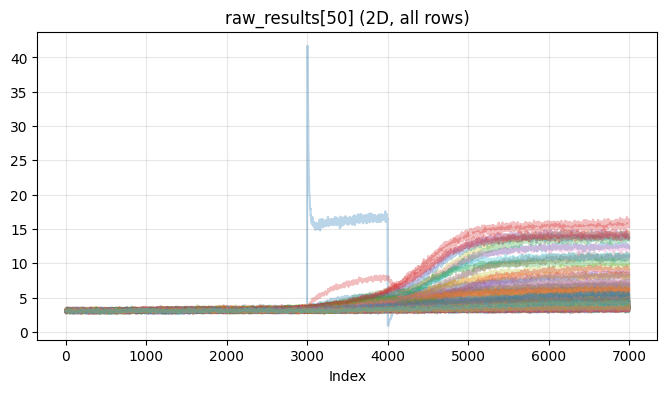

--- Plotting raw_results[51] ---


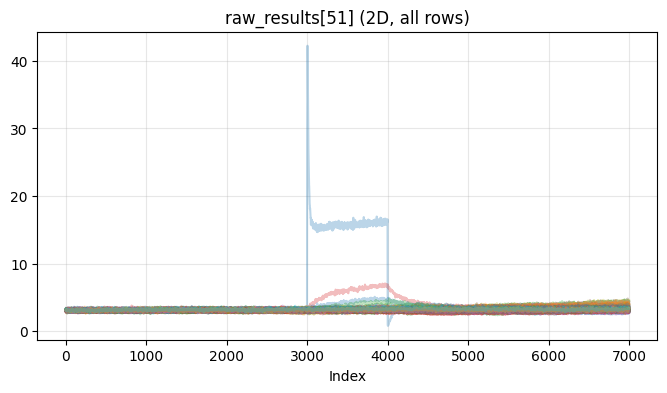

--- Plotting raw_results[52] ---


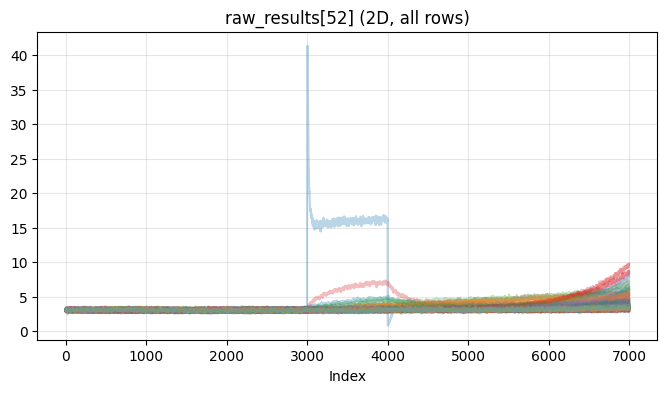

--- Plotting raw_results[53] ---


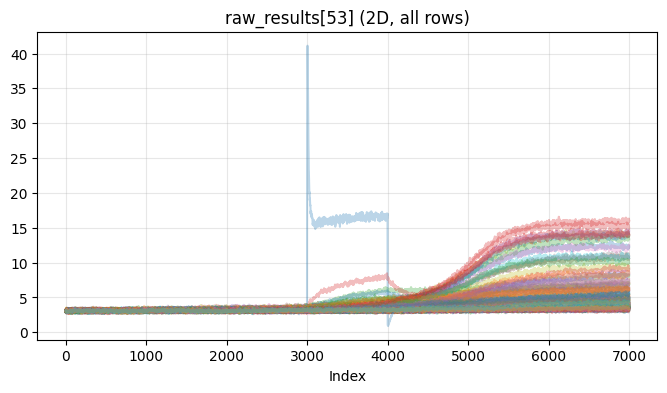

--- Plotting raw_results[54] ---


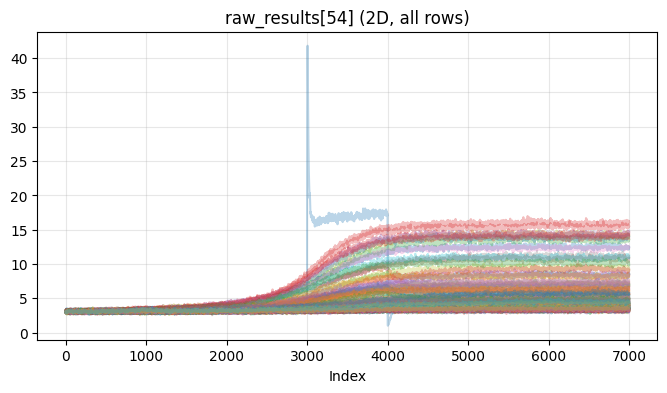

--- Plotting raw_results[55] ---


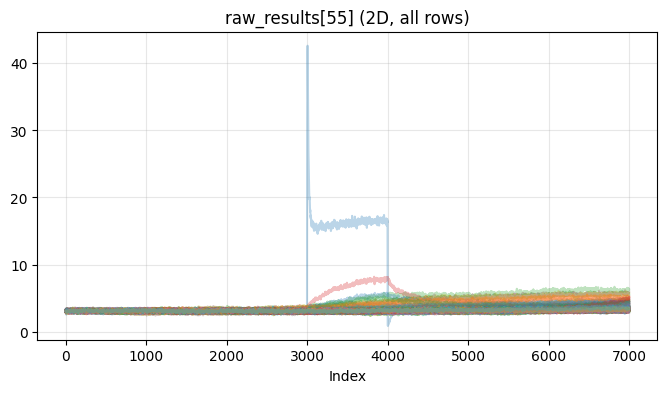

--- Plotting raw_results[56] ---


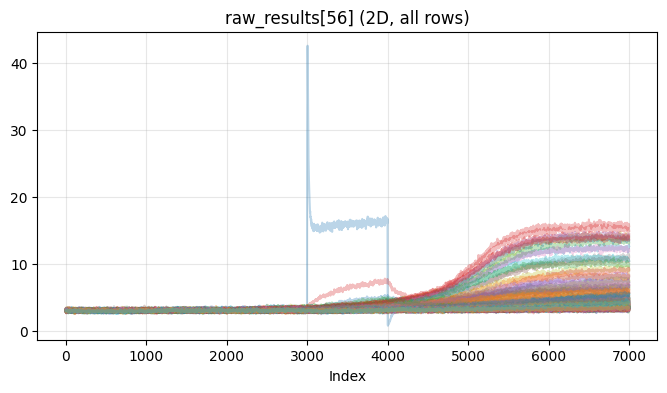

--- Plotting raw_results[57] ---


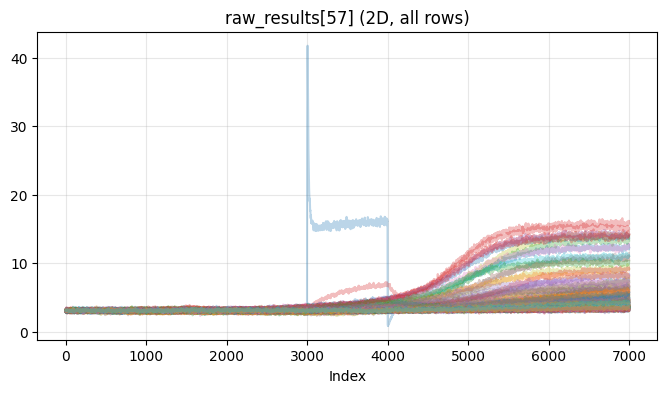

--- Plotting raw_results[58] ---


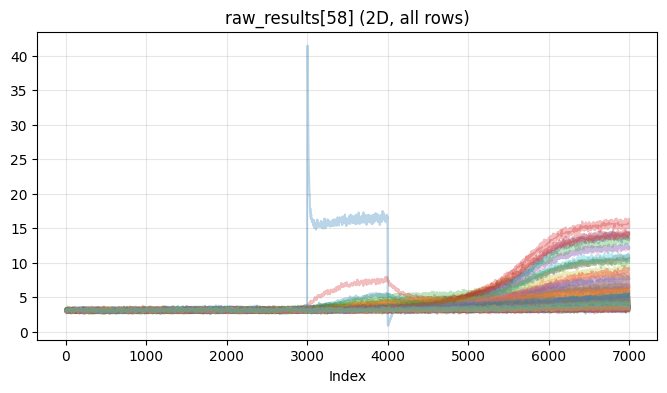

--- Plotting raw_results[59] ---


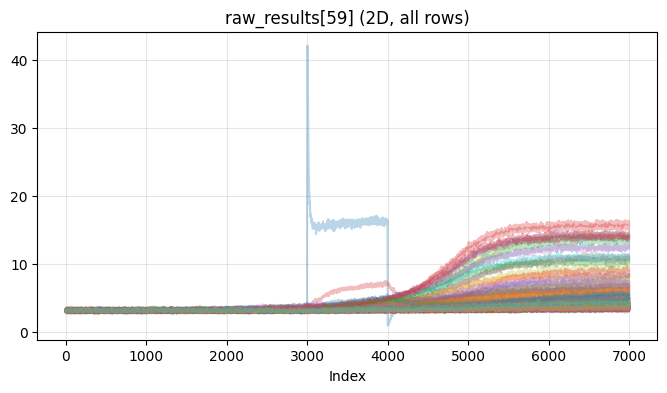

--- Plotting raw_results[60] ---


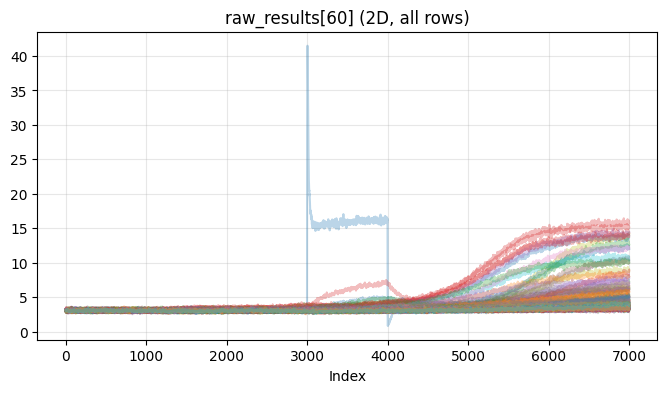

--- Plotting raw_results[61] ---


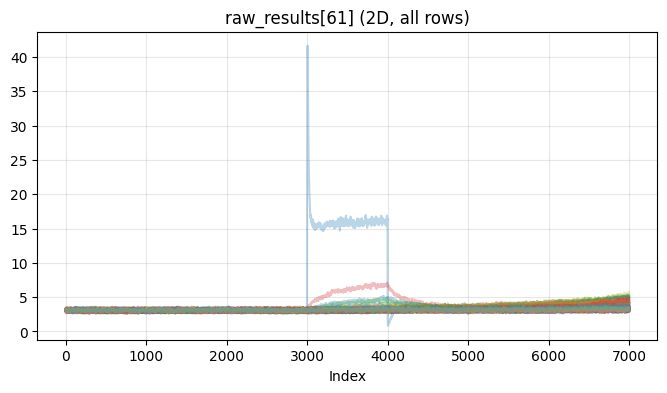

--- Plotting raw_results[62] ---


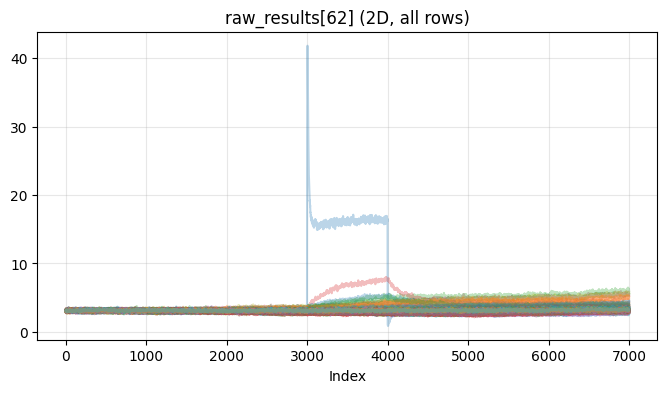

--- Plotting raw_results[63] ---


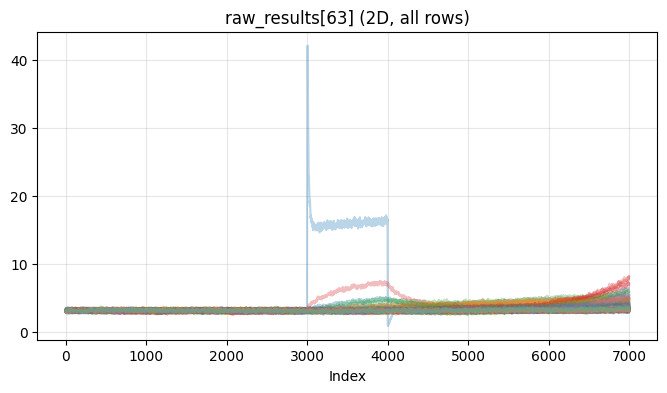

--- Plotting raw_results[64] ---


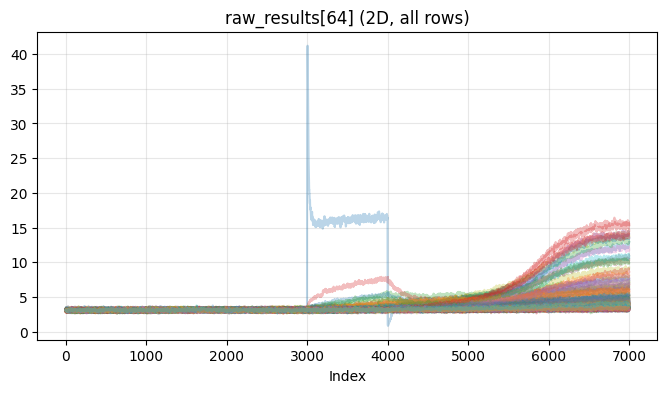

--- Plotting raw_results[65] ---


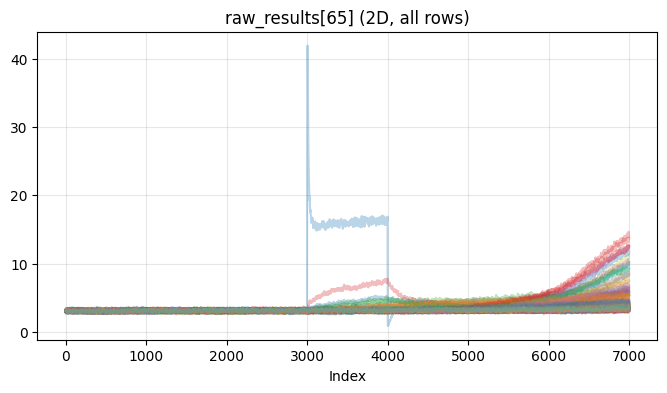

--- Plotting raw_results[66] ---


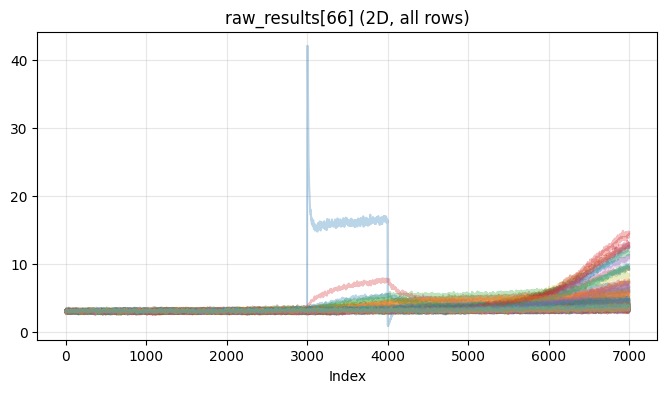

--- Plotting raw_results[67] ---


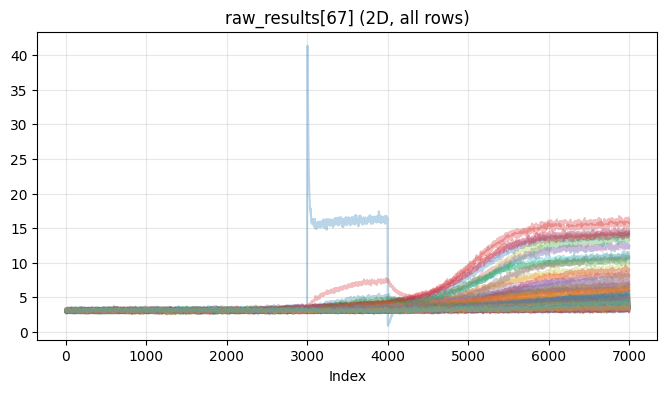

--- Plotting raw_results[68] ---


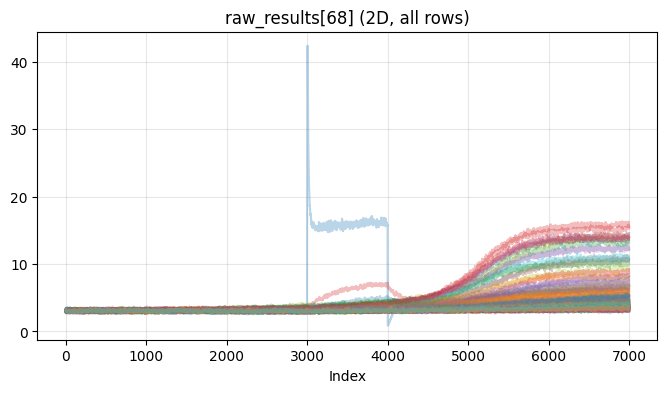

--- Plotting raw_results[69] ---


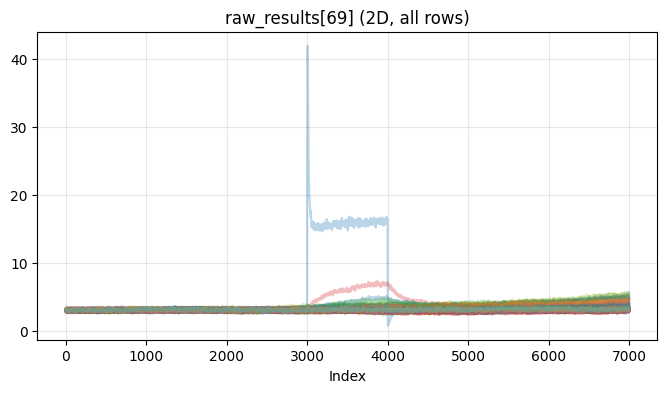

--- Plotting raw_results[70] ---


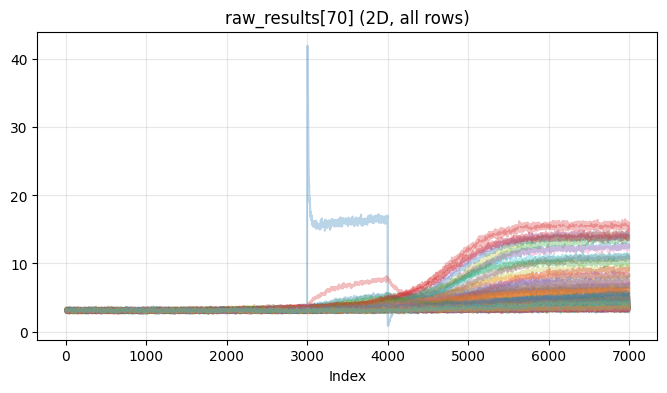

--- Plotting raw_results[71] ---


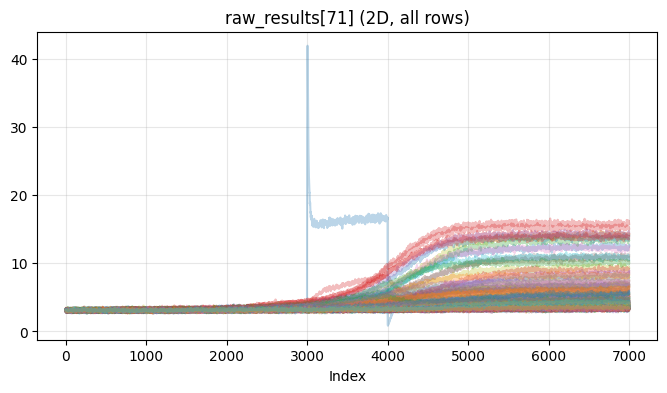

--- Plotting raw_results[72] ---


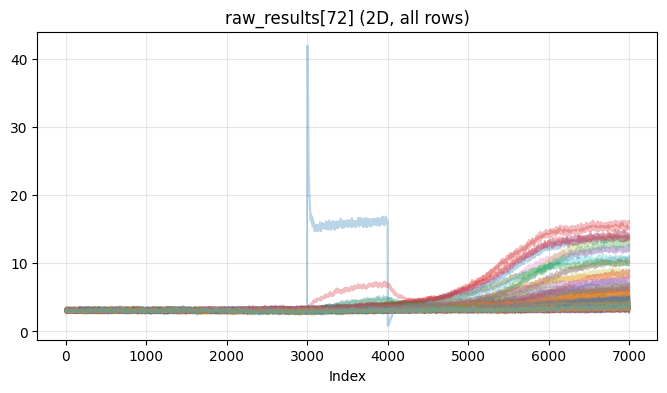

--- Plotting raw_results[73] ---


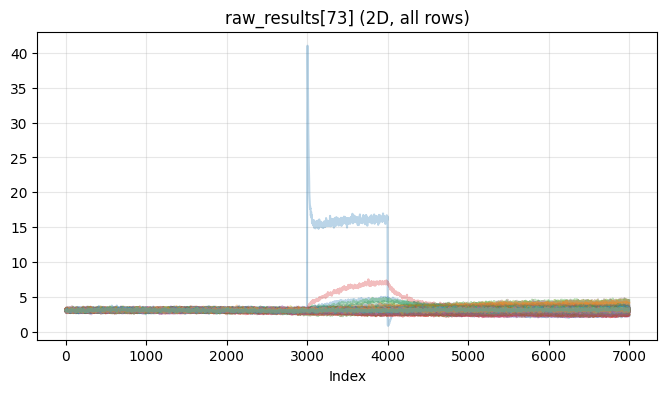

--- Plotting raw_results[74] ---


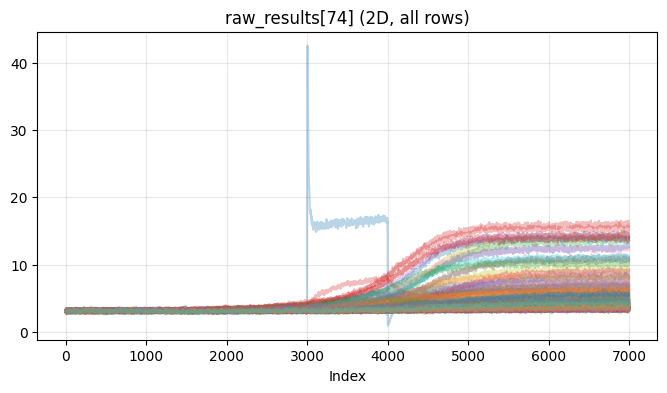

--- Plotting raw_results[75] ---


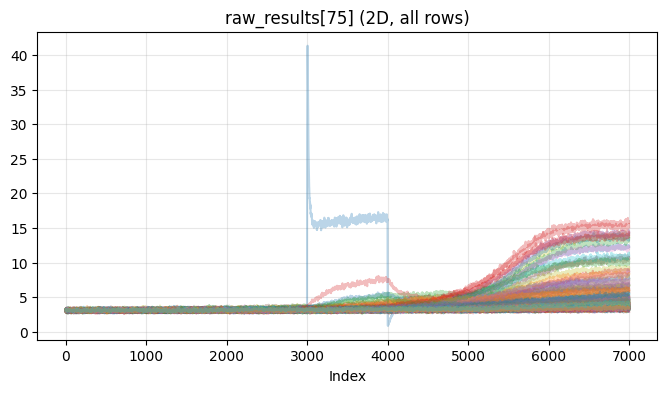

--- Plotting raw_results[76] ---


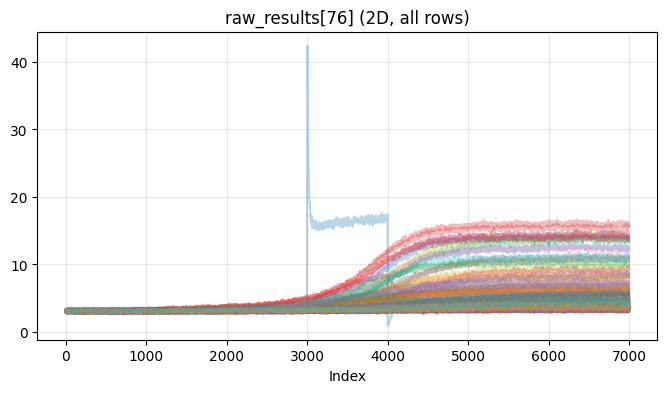

--- Plotting raw_results[77] ---


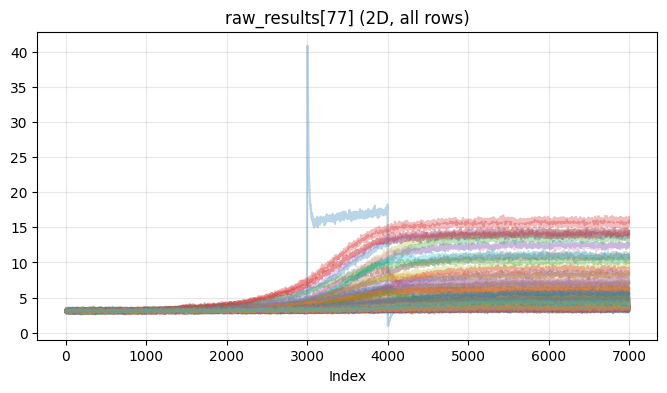

--- Plotting raw_results[78] ---


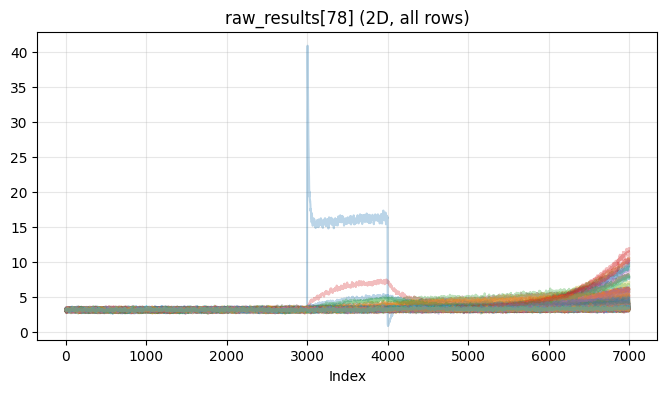

--- Plotting raw_results[79] ---


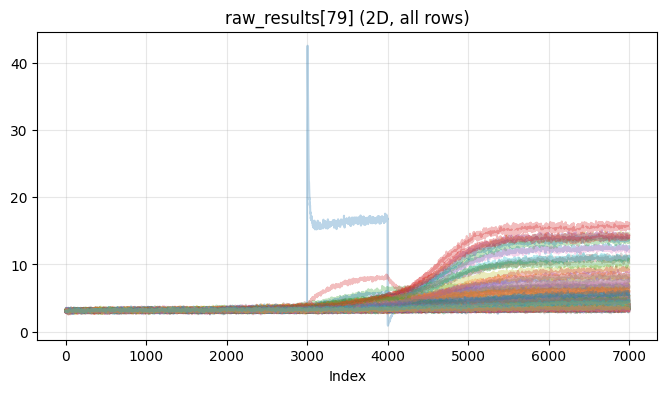

--- Plotting raw_results[80] ---


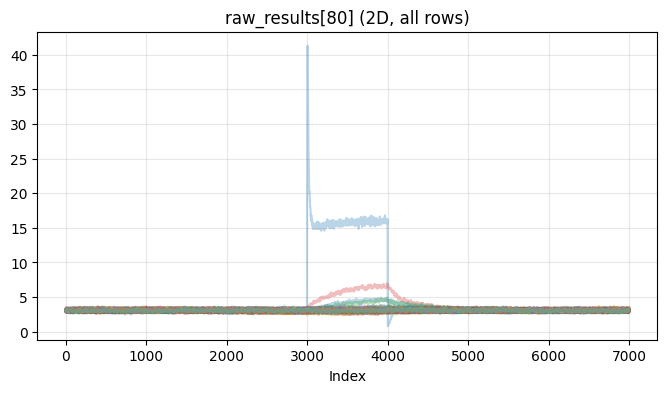

--- Plotting raw_results[81] ---


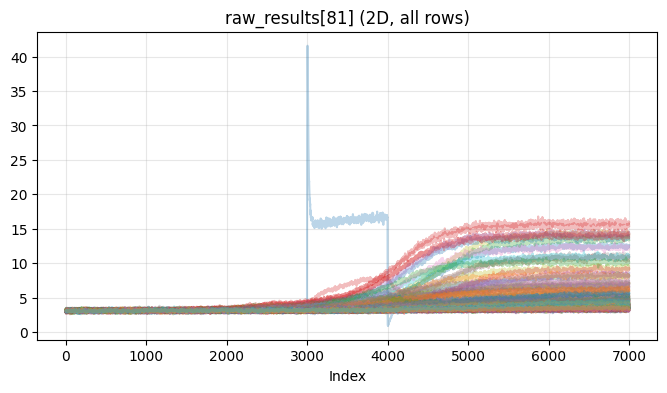

--- Plotting raw_results[82] ---


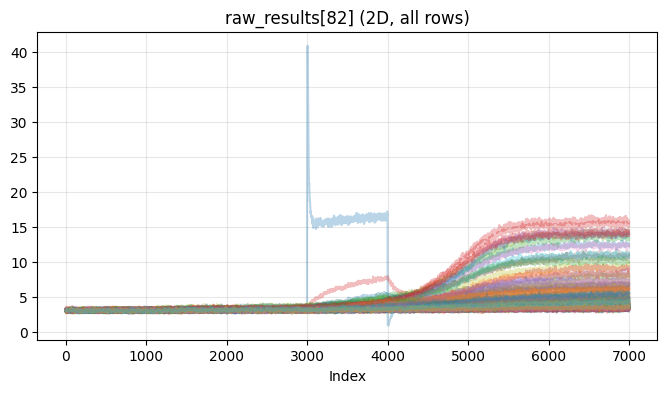

--- Plotting raw_results[83] ---


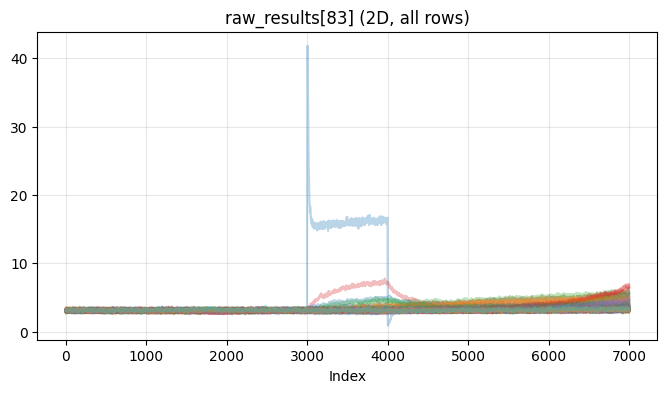

--- Plotting raw_results[84] ---


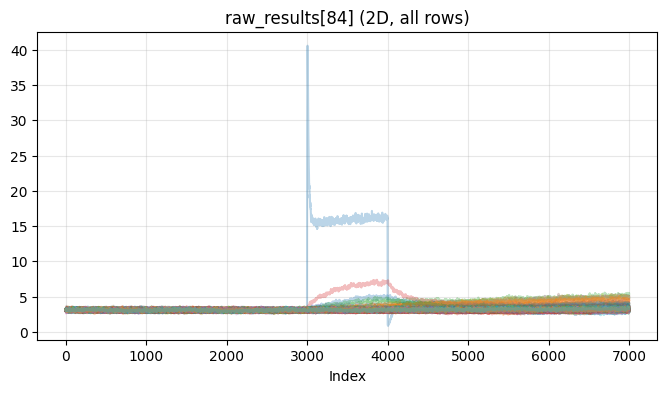

--- Plotting raw_results[85] ---


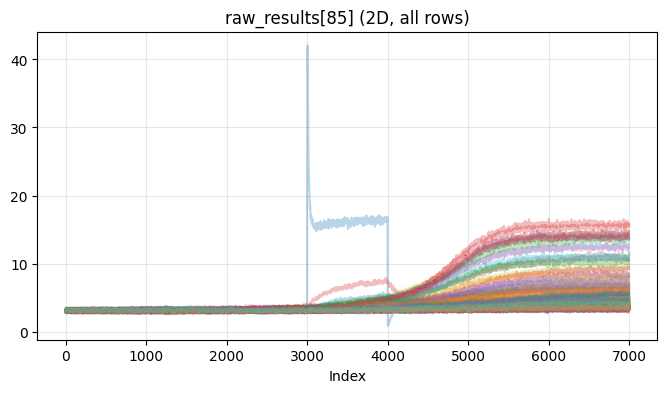

--- Plotting raw_results[86] ---


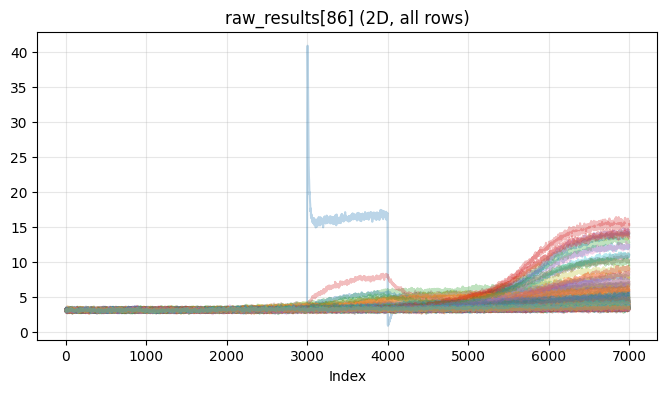

--- Plotting raw_results[87] ---


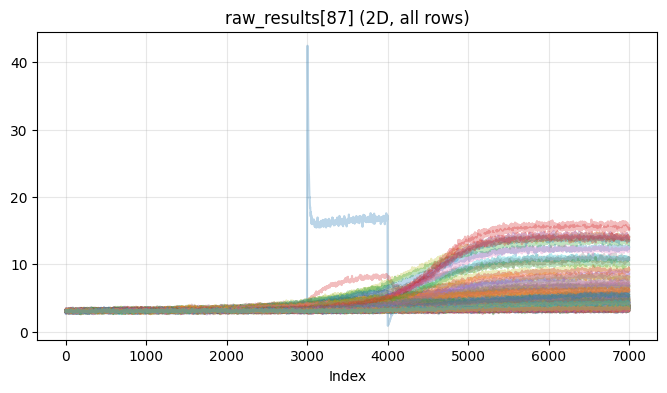

--- Plotting raw_results[88] ---


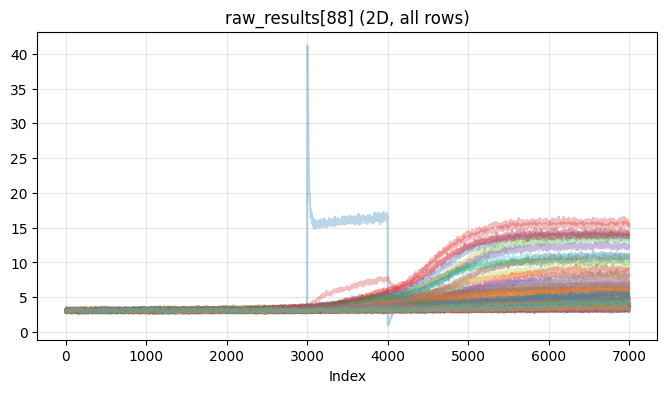

--- Plotting raw_results[89] ---


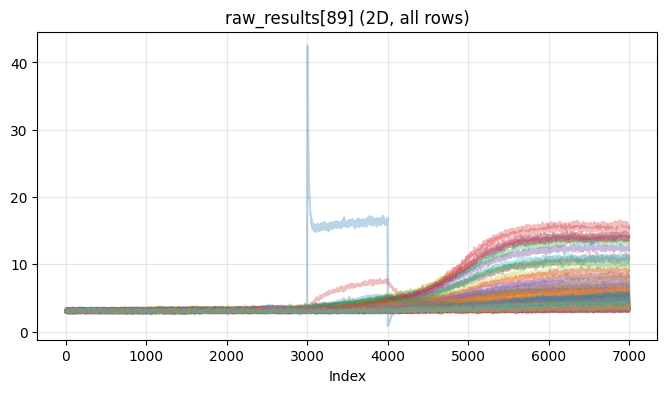

--- Plotting raw_results[90] ---


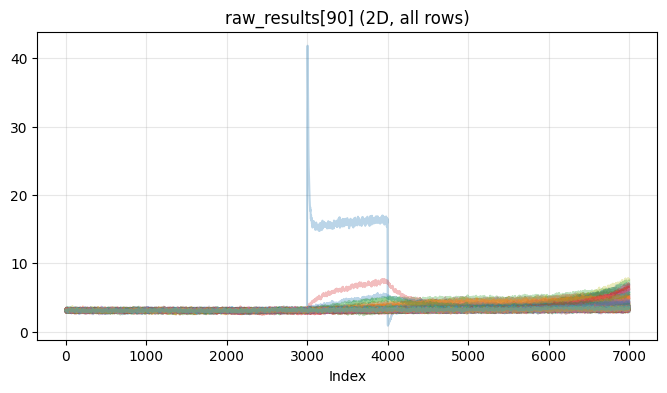

--- Plotting raw_results[91] ---


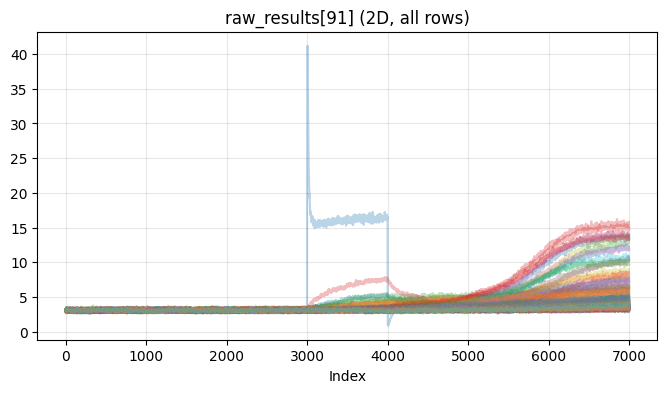

--- Plotting raw_results[92] ---


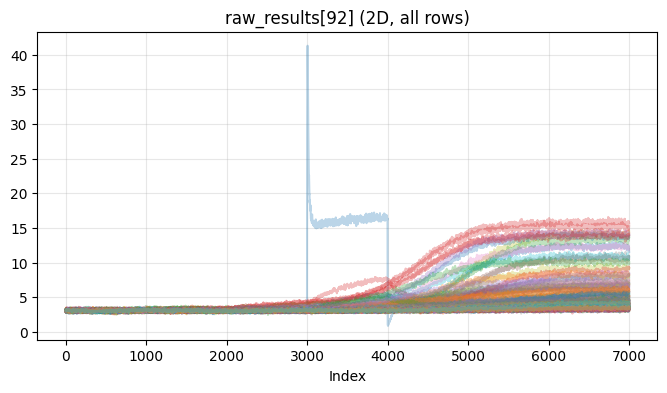

--- Plotting raw_results[93] ---


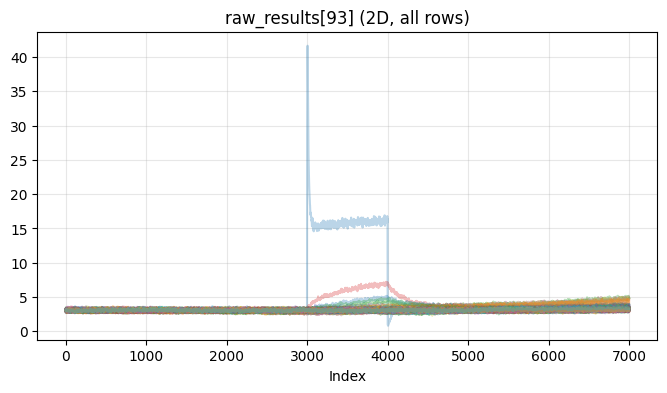

--- Plotting raw_results[94] ---


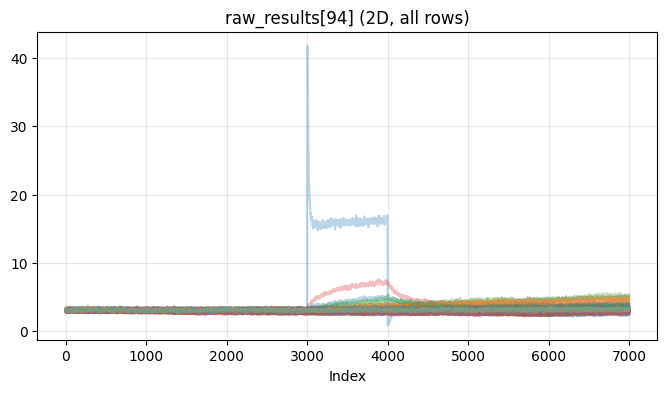

--- Plotting raw_results[95] ---


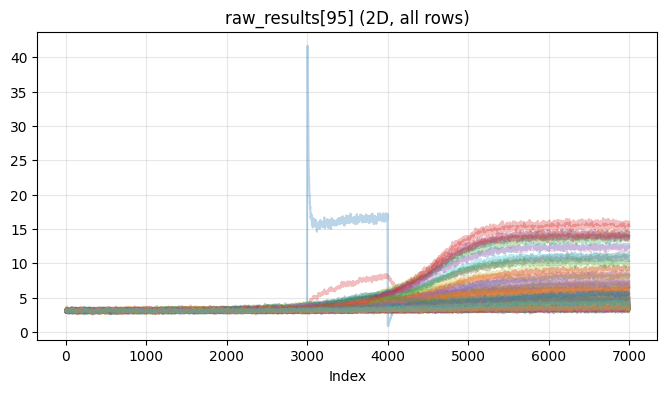

--- Plotting raw_results[96] ---


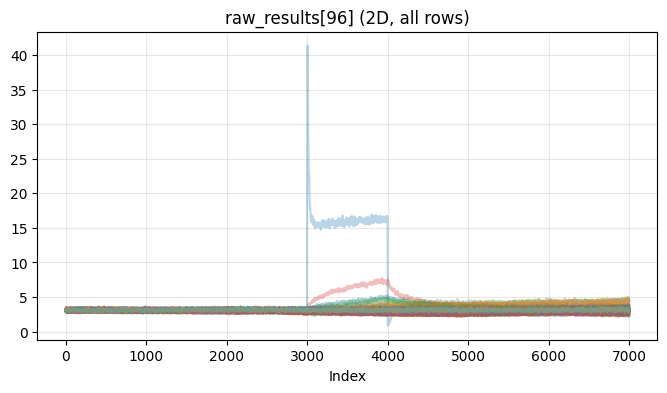

--- Plotting raw_results[97] ---


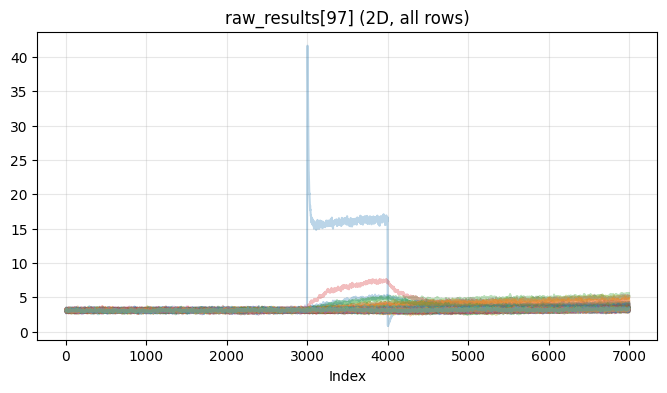

--- Plotting raw_results[98] ---


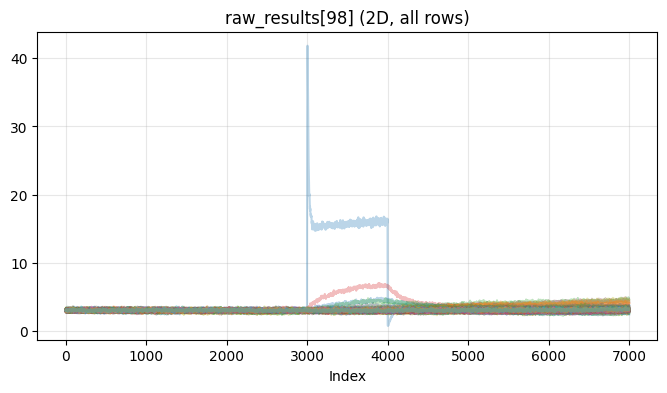

--- Plotting raw_results[99] ---


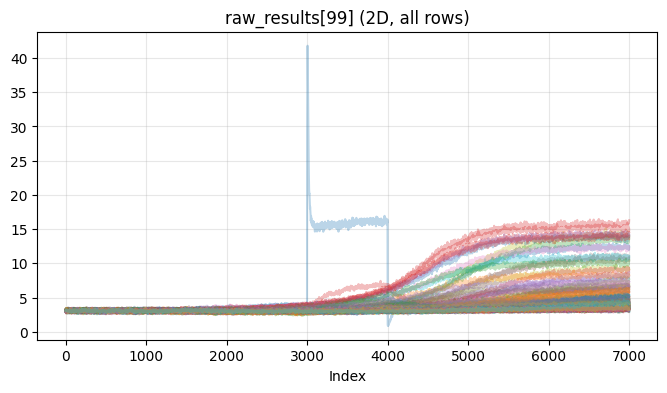

In [24]:
# Plot the contents of raw_results[0] if possible
import matplotlib.pyplot as plt
import numpy as np

# Plot all 100 results in raw_results
for idx, result in enumerate(raw_results[:100]):
    print(f"--- Plotting raw_results[{idx}] ---")
    if isinstance(result, dict):
        # Try to find keys that look like timeseries
        for key, val in result.items():
            if isinstance(val, (np.ndarray, list)) and np.array(val).ndim in [1, 2]:
                plt.figure(figsize=(8, 4))
                arr = np.array(val)
                if arr.ndim == 1:
                    plt.plot(arr)
                    plt.title(f"raw_results[{idx}]: {key} (1D)")
                    plt.xlabel("Index")
                    plt.ylabel(key)
                elif arr.ndim == 2:
                    for i in range(arr.shape[0]):
                        plt.plot(arr[i], alpha=0.3)
                    plt.title(f"raw_results[{idx}]: {key} (2D, all rows)")
                    plt.xlabel("Index")
                    plt.ylabel(key)
                plt.grid(True, alpha=0.3)
                plt.show()
    elif isinstance(result, (np.ndarray, list)):
        arr = np.array(result)
        plt.figure(figsize=(8, 4))
        if arr.ndim == 1:
            plt.plot(arr)
            plt.title(f"raw_results[{idx}] (1D)")
            plt.xlabel("Index")
        elif arr.ndim == 2:
            for i in range(arr.shape[0]):
                plt.plot(arr[i], alpha=0.3)
            plt.title(f"raw_results[{idx}] (2D, all rows)")
            plt.xlabel("Index")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"raw_results[{idx}]:", result)


### Data Saving - Only save when you're 100% satisfied of the results

In [10]:
# Save complete experiment results
#saver = ResultsSaver(config)
#output_file = saver.save_experiment(
#    raw_results, decay_data, timescale_results, "/home/frank/HBNM/experiments/INTs/INT_Results/experiment_results.hdf5"
#)